In [2]:
#Import libraries 
import csv
import os
import shutil
import warnings
import zipfile
import sys

import cv2
import pickle
import kagglehub
import random
import time
import re
import optuna
import json

import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import HTML

from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [4]:

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)              # CPU RNG
    torch.cuda.manual_seed(seed)         # current GPU
    torch.cuda.manual_seed_all(seed)     # all GPUs, in case of multi-GPU

    # Force deterministic algorithms where available 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    """Use this as worker_init_fn= in DataLoader so each worker
    process gets a reproducible (but distinct) seed too. Without this,
    num_workers > 0 reintroduces randomness even after set_seeds()."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seeds(42)
g = torch.Generator()
g.manual_seed(42)

In [5]:
# This automatically picks GPU if available, otherwise stays on CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}  | num GPUs: {torch.cuda.device_count()}")
N_WORKERS = min(4, os.cpu_count())

Using device: cuda  | num GPUs: 2


# Data loading

The SMG dataset we are using in this project is an already preprocessed version (SMGskeleton) provided by the original authors. It is composed by four files: two .npy files corresponding to the 5d-tensor with the skeleton sequences, and two .pkl files with the labels of both training and testing sets. The labels file is a tuple where the first position corresponds to the sample code, which is formed by the user ID in a 4 digits form, and the gesture number. For example, if the user ID is 4, the first 5 gestures of this user would be saved as: Sample00040, Sample00041, Sample00042, Sample00043, Sample00044.

We will first extract the user ID from the sample name syntaxis explained before. Posterior to data we will save the indexes of the gestures corresponding to the first 30 users for training, and we will leave the other 5 users remaining for the validation. This is a very relevant step, since it prevents data leakage. Otherwise, the validation set is not a trustable reference of the model's performance since it provides extremely similar data than the training set, since a person may tend to repeat the same gestures. The gestures per user were actually saved in order, so we can simply take the first 2,452 gestures for training and the last 637 elements for validation.

The raw data (experimentWell_skeleton) was composed by 40 folders containing three .txt files: data, finelabels and skeleton. The data file contain three variables corresponding to the number of frames in the video, the resolution in frames per seconds (fps) and the maximum depth. The second file, finelabels, contains three variables encoding the gestureID, the starting and ending frame off all the microgestures performed during the whole recording. In this case, each row represents a different MG. Finally, the skeleton variable contains the coordinates for every frame.

In [6]:
# Download latest version of dataset 
path = kagglehub.dataset_download("dandrade05/smg-dataset")

print("Path to dataset files:", path)

#Data paths
train_path='/kaggle/input/datasets/dandrade05/smg-dataset/train_data.npy'
train_y_path='/kaggle/input/datasets/dandrade05/smg-dataset/train_label.pkl'
test_path='/kaggle/input/datasets/dandrade05/smg-dataset/test_data.npy'
test_y_path='/kaggle/input/datasets/dandrade05/smg-dataset/test_label.pkl'

#Function to import data into variables
def import_data(path, labels=False):
    if labels:
        with open(path, 'rb') as f:
            sample_names, labels = pickle.load(f)
            return sample_names, labels

    else:
        data= np.load(path)
    
    return data

#Function to extract the user ID from the name 
def get_subject_id(name):
    match = re.match(r'Sample(\d{4})(\d+)', name)
    if match:
        return int(match.group(1))   # subject 1–40
    return None
        
class SMGDataset(Dataset):
    """
    Wraps the SMG skeleton tensor and its labels.

    Expected inputs
    ---------------
    data   : np.ndarray of shape (N, C, T, V, M) = (3089, 3, 90, 25, 1)
    labels : np.ndarray of shape (N,), integer class indices starting from 0

    Data augmentation (training only)
    ----------------------------------
    - Random horizontal flip (mirror left/right joints)
    - Random temporal crop / padding to keep fixed T
    - Gaussian noise injection on coordinates
    """

    # Mirror pairs for the 25-joint skeleton (left ↔ right)
    MIRROR_PAIRS = [
        (4, 8), (5, 9), (6, 10), (7, 11),   # arms
        (21, 23), (22, 24),                   # hand tips
        (12, 16), (13, 17), (14, 18), (15, 19),  # legs
    ]

    def __init__(self, data: np.ndarray, labels: np.ndarray,
                 augment: bool = False,
                 noise_std: float = 0.01,
                 temporal_crop: bool = True):
        self.data    = torch.tensor(data,   dtype=torch.float32)
        self.labels  = torch.tensor(labels, dtype=torch.long)
        self.augment = augment
        self.noise_std = noise_std
        self.temporal_crop = temporal_crop
        self.T = data.shape[2]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.data[idx].clone()   # (C, T, V, M)
        y = self.labels[idx]

        if self.augment:
            x = self._random_flip(x)
            x = self._add_noise(x)
            if self.temporal_crop:
                x = self._temporal_crop(x)

        return x, y

    def _random_flip(self, x):
        if torch.rand(1) < 0.5:
            x[0] = -x[0]    # mirror x-axis
            for i, j in self.MIRROR_PAIRS:
                x[:, :, i, :], x[:, :, j, :] = x[:, :, j, :].clone(), x[:, :, i, :].clone()
        return x

    def _add_noise(self, x):
        return x + torch.randn_like(x) * self.noise_std

    def _temporal_crop(self, x):
        """Randomly crop T frames, with reflection padding if sequence is short."""
        max_shift = max(1, self.T // 10)   # shift up to 10% of frames
        shift = torch.randint(0, max_shift, (1,)).item()
        direction = 1 if torch.rand(1) < 0.5 else -1
        x = torch.roll(x, shifts=direction * shift, dims=1)
        return x

# ---------------------------------------------------------------------------
# WeightedRandomSampler — balance batches at the DataLoader level
# ---------------------------------------------------------------------------

def make_weighted_sampler(labels):
    """
    Build a WeightedRandomSampler so each mini-batch sees roughly balanced
    classes regardless of the dataset distribution.
    """
    labels = np.array(labels)
    counts = np.bincount(labels)
    weight_per_class = 1.0 / counts.astype(np.float64)
    sample_weights = torch.tensor(weight_per_class[labels], dtype=torch.float64)
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )

#Call function
all_train_data = import_data(train_path)
all_train_names, all_train_labels = import_data(train_y_path, labels=True)
test_data = import_data(test_path)
test_names, test_labels = import_data(test_y_path, labels=True)

#We only do this to properly split the training set into a training and validation se
#using exact user 1-30 for training and 31-35 for validation (to avoid data leakage)
subject_ids = [get_subject_id(n) for n in all_train_names]
train_idx = [i for i, s in enumerate(subject_ids) if s <= 30]
val_idx   = [i for i, s in enumerate(subject_ids) if 31 <= s <= 35]

train_data   = all_train_data[train_idx]
train_labels = [all_train_labels[i] for i in train_idx]
train_names  = [all_train_names[i]  for i in train_idx]

val_data   = all_train_data[val_idx]
val_labels = [all_train_labels[i] for i in val_idx]
val_names  = [all_train_names[i]  for i in val_idx]

#Lets turn the list of labels into an array
train_labels_np = np.array(train_labels)
val_labels_np = np.array(val_labels)
test_labels_np = np.array(test_labels)

print('Check dataset dimensions')
print('TRAINING DATA')
print('Training set:', train_data.shape)
print(f"Total samples: {len(train_data)}")
print(f"Samples per class: {np.bincount(train_labels)}")
print('Classes: 0-17')
print(f'-----------------------------------------------')

print('VALIDATION DATA')
print('Validation set:', val_data.shape)
print(f"Total samples: {len(val_data)}")
print(f"Samples per class: {np.bincount(val_labels)}")
print('Classes: 0-17')
print('-----------------------------------------------')

print('TESTING DATA')
print('Testing set:', test_data.shape)
print(f"Total samples: {len(test_data)}")
print(f"Samples per class: {np.bincount(test_labels)}")
print('Classes: 0-13, 16')

train_ds = SMGDataset(train_data, train_labels_np, augment=True)
val_ds   = SMGDataset(val_data,   val_labels_np,   augment=False)
test_ds  = SMGDataset(test_data,  test_labels_np,  augment=False)

Path to dataset files: /kaggle/input/datasets/dandrade05/smg-dataset
Check dataset dimensions
TRAINING DATA
Training set: (2452, 3, 90, 25, 1)
Total samples: 2452
Samples per class: [ 40  48 175   9 720  21 101 249 724  11  14 167  41  63  11  19  39]
Classes: 0-17
-----------------------------------------------
VALIDATION DATA
Validation set: (637, 3, 90, 25, 1)
Total samples: 637
Samples per class: [  3   0   7   0 384   2  22   6 156   5   2  23  19   1   0   2   5]
Classes: 0-17
-----------------------------------------------
TESTING DATA
Testing set: (610, 3, 90, 25, 1)
Total samples: 610
Samples per class: [ 13   3  15   2  49   1   3 191 243  34   8  30   4   5   0   0   9]
Classes: 0-13, 16


In [7]:
#Saving only training set 
np.save('train_data_fixed', train_data)
with open('train_labels_tuple.pkl', 'wb') as file:
    pickle.dump((train_names, train_labels), file)

#Saving only validation set 
np.save('val_data', val_data)
with open('val_labels_tuple.pkl', 'wb') as file:
    pickle.dump((val_names, val_labels), file)

In [8]:
print(len(train_names))
print(len(train_data))
print(len(train_labels))
print(len(val_names))
print(len(val_data))
print(len(val_labels))

2452
2452
2452
637
637
637


In [9]:
val_data.shape

(637, 3, 90, 25, 1)

Now, we know the training set has the following dimensions: (3089, 3, 90, 25, 1). This structure follows the standard convention for Spatio-Temporal Graph Convolutional Networks (ST-GCN), which is the most common architecture for skeleton-based gesture recognition. The 5d-tensor structured as (N,C,T,V,M) represents respectively:
* N - Samples (3089): Total number of video clips or gesture sequences in your training set.
* C - Channels (3): These are the spatial coordinates. Specifically:
  * Index 0: X coordinate
  * Index 1: Y coordinate
  * Index 2: Z coordinate (Depth)
* T - Time/Frames (90): It's the length of the input sequence, which is the temporal dimension. Each gesture sequence is normalized to 90 frames.
* V - Vertices/Joints (25): These are the number of joints tracked per person, which will correspond to the number of graph nodes. In the SGM and similar datasets (like NTU-RGB+D), 25 joints represent the full body (head, neck, spine, elbows, wrists, etc.)
* M - (1): This is the number of persons in a frame

To visualize the data, we need to select a single sample and a single frame, then plot the joints as points in a 3D space. To make it recognizable, we will connect the points using a "bone mapping."

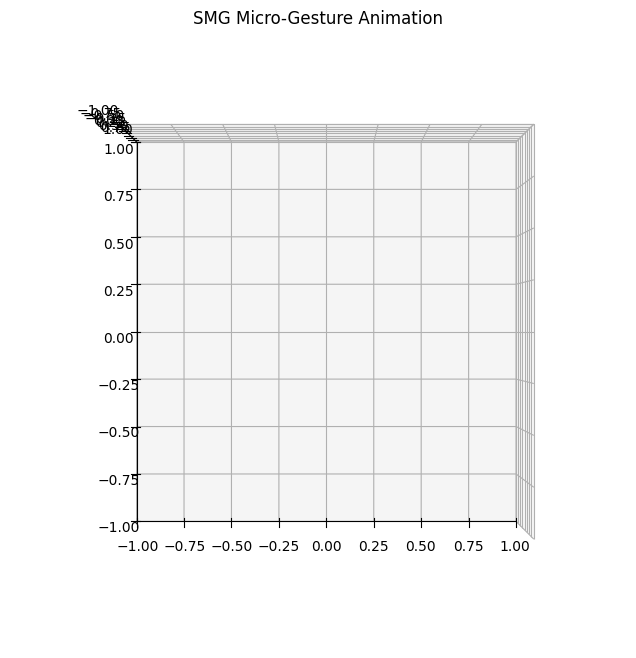

In [10]:
# The standard Kinect v2 / NTU-RGBD joint connection map
# Converted to 0-based indexing for the (25,) dimension
bones = [
    (0, 1), (1, 20), (20, 2), (2, 3),          # spine + head
    (20, 4), (4, 5), (5, 6), (6, 7),            # left arm
    (7, 21), (7, 22),                            # left hand tips
    (20, 8), (8, 9), (9, 10), (10, 11),         # right arm
    (11, 23), (11, 24),                          # right hand tips
    (0, 12), (12, 13), (13, 14), (14, 15),      # left leg
    (0, 16), (16, 17), (17, 18), (18, 19),      # right leg
]

# bones_1based = [
#     (1, 2), (2, 21), (21, 3), (3, 4),           # spine + head
#     (21, 5), (5, 6), (6, 7), (7, 8),            # left arm
#     (8, 22), (8, 23),                            # left hand tips
#     (21, 9), (9, 10), (10, 11), (11, 12),       # right arm
#     (12, 24), (12, 25),                          # right hand tips
#     (1, 13), (13, 14), (14, 15), (15, 16),      # left leg
#     (1, 17), (17, 18), (18, 19), (19, 20),      # right leg
# ]

#Function to plot one example
def animate_skeleton(sample_data): 
    #sample_data: Input tensor of shape (3, 90, 25, 1)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Initialize scatter for joints and list for bone lines
    points = ax.scatter([], [], [], c='red', s=30)
    lines = [ax.plot([], [], [], c='blue', linewidth=2)[0] for _ in bones]

    # Set axis limits (Adjustment may be needed based on data normalization)
    ax.set_xlim3d([-1, 1])
    ax.set_ylim3d([1, -1])
    ax.set_zlim3d([-1, 1])
    
    # Adjust view to see the skeleton upright
    ax.view_init(elev=-90, azim=-90)

    def update(frame):
        # Extract coordinates for current frame
        x = sample_data[0, frame, :, 0]
        y = sample_data[1, frame, :, 0]
        z = sample_data[2, frame, :, 0]

        # Update joint positions
        points._offsets3d = (x, y, z)

        # Update bone (line) positions
        for i, (start, end) in enumerate(bones):
            lines[i].set_data([x[start], x[end]], [y[start], y[end]])
            lines[i].set_3d_properties([z[start], z[end]])

        return [points] + lines

    # Create animation
    ani = animation.FuncAnimation(
        fig, update, frames=90, interval=50, blit=False
    )

    plt.title("SMG Micro-Gesture Animation")
    plt.show()
    return ani

# Usage:
ani = animate_skeleton(train_data[154])
HTML(ani.to_jshtml())  # This creates a video player inside the notebook

In [11]:
print(all_train_labels[154])
ani.save(filename="ex_class15.gif")

15


Previously we managed to visualize the gesture coordinate. Now, it's neccesary to extract the corresponding label for each gesture. Based on the paper, 16 microgestures (MG) were identified:

1. Turtling neck and shoulder (Freezing)
2. Rubbing eyes and forehead (Freezing)
3. Folding arms (Fighting)
4. Touching or covering suprasternal notch (Pacifying)
5. Moving legs (Fleeing)
6. Touching or scratching neck (Pacifying)
7. Folding arms behind body (Freezing)
8. Rubbing hands and crossing finger (Pacifying)
9. Arms akimbo (Fighting)
10. Crossing legs (Pacifying)
11. Scratching some part of body (Pacifying)
12. Scratching or touching facial parts other than eyes (Pacifying)
13. Playing or adjusting hair (Pacifying)
14. Holding arms (Fighting)
15. Pulling shirt collar (Pacifying)
16. Playing with jewelry and manipulating other objects (Pacifying)
17. Non-MGs (Illustrative hand gestures)

The number corresponds to the gesture ID or label, and the word in parenthesis is the psychological basis that drives the corresponding micro-gesture. For example, gestures with the fight attribute are typically related to anger, aggression or violence (Algarin et al., 2026).

In the train_labels variable we have a tuple with two lists, the first one corresponds to all the Sample IDs and the second one to the labels. However, since there's no any Sample ID in the skeleton data, we can ignore the first list, and only keep the labels under the assumption that the skeleton data and the label list's order match. In this way, the skeleton coordinates and the label can both be accesible through the index position. 

# Pre-processing 

The SMGskeleton data is already preprocessed; however, it is relevant to check which preprocessing techniques have been applied to the data, and later determine if further action is required. In this section we will check:
* Normalization
* Padding: Zero-padding applied at the end of the sequence. In this way all sequences contain exactly 90 frames.
* Translation to center
* Paralleling of joints to axes

In [52]:
# CHECK FOR EXTREME VALUES
def check_axis_ranges(data_tensor):
    axes_names = ['X-axis', 'Y-axis', 'Z-axis']
    
    # Iterate through each channel in the C dimension (index 1)
    for i in range(data_tensor.shape[1]):
        axis_data = data_tensor[:, i, :, :, :]
        
        min_val = np.min(axis_data)
        max_val = np.max(axis_data)
        mean_val = np.mean(axis_data) #Check center point, should be the hip based on the animation example
        
        name = axes_names[i] if i < len(axes_names) else f"Axis-{i}"
        
        print(f"--- {name} ---")
        print(f"  Min:  {min_val:.4f}")
        print(f"  Max:  {max_val:.4f}")
        print(f"  Mean: {mean_val:.4f}\n") 

print("Train set statistics")
check_axis_ranges(train_data)
print("Test set statistics")
check_axis_ranges(test_data)


Train set statistics
--- X-axis ---
  Min:  -1.7137
  Max:  0.8286
  Mean: -0.0004

--- Y-axis ---
  Min:  -1.2990
  Max:  0.9034
  Mean: -0.0381

--- Z-axis ---
  Min:  0.0000
  Max:  3.2026
  Mean: 1.0578

Test set statistics
--- X-axis ---
  Min:  -0.8098
  Max:  0.5705
  Mean: 0.0039

--- Y-axis ---
  Min:  -1.4775
  Max:  0.8884
  Mean: -0.0477

--- Z-axis ---
  Min:  0.0000
  Max:  2.8890
  Mean: 0.7656



In [14]:
#REVIEW ZERO-PADDING
# Pick a random index
idx = 55 

# Get the skeleton data for that index
sample_data = train_data[idx] # Shape: (C, T, V, M)

# Check the 'real' number of frames (ignoring zero-padding)
# We sum across all dimensions except time (T) to see which frames have data

real_frame_count = np.sum(np.abs(sample_data).sum(axis=(0, 2, 3)) > 0)

print(f"Data at index {idx} has {real_frame_count} active frames.")
print(f"Label ID for this index is: {train_labels_np[idx]}")

#Since the active frames is <90, it means padding was applied to make all sequences
#have the same length. In this example we have only 62 active frames, and we can confirm the padding was applied at 
#end of the sequences by running the following line

print("All the zero values are found at the end of the sequence")
print(np.abs(sample_data).sum(axis=(0, 2, 3)) > 0)

Data at index 55 has 62 active frames.
Label ID for this index is: 0
All the zero values are found at the end of the sequence
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False]


In [29]:
N, C, T, V, M = train_data.shape

# Identify real vs. null-padded frames
# A padded frame has all joints at (0,0,0,...) across C and V
frame_energy = np.abs(train_data).sum(axis=(1, 3))       # [N, T, M]
valid_mask = frame_energy > 1e-8                          # True where frame is real

# VERIFY TRANSLATION TO CENTER
center_joint = 0  # SpineBase
center_coords = train_data[:, :, :, center_joint, :]      # [N, C, T, M]
center_norm = np.linalg.norm(center_coords, axis=1)        # [N, T, M]

valid_center_norm = center_norm[valid_mask]
print("Center joint deviation from origin (should be ~0):")
print(f"  mean: {valid_center_norm.mean():.8f}")
print(f"  max:  {valid_center_norm.max():.8f}")
print(f"  % of frames within 1e-4: {(valid_center_norm < 1e-4).mean()*100:.2f}%")

# VERIFY PARALLELING OF JOINTS TO AXES 
# common convention: spine vector -> one axis, shoulder line -> another axis
spine_base, spine_mid   = 0, 1     # vector defining "vertical" alignment
shoulder_l, shoulder_r  = 4, 8      # vector defining "horizontal" alignment

def unit_vectors(a_idx, b_idx):
    a = train_data[:, :, :, a_idx, :]
    b = train_data[:, :, :, b_idx, :]
    v = b - a                                              # [N, C, T, M]
    norm = np.linalg.norm(v, axis=1, keepdims=True)
    norm[norm < 1e-8] = 1.0                                 # avoid /0 on padded frames
    return v / norm

spine_vec    = unit_vectors(spine_base, spine_mid)
shoulder_vec = unit_vectors(shoulder_l, shoulder_r)

target_spine    = np.array([0, 1, 0]).reshape(1, 3, 1, 1)   # e.g. Y-axis
target_shoulder = np.array([1, 0, 0]).reshape(1, 3, 1, 1)   # e.g. X-axis

cos_spine = np.clip((spine_vec * target_spine).sum(axis=1), -1, 1)       # [N,T,M]
angle_spine_deg = np.degrees(np.arccos(cos_spine))

cos_shoulder = np.clip((shoulder_vec * target_shoulder).sum(axis=1), -1, 1)
angle_shoulder_deg = np.degrees(np.arccos(cos_shoulder))

print("\nSpine-to-axis angle (deg, should be ~0):")
print(f"  mean: {angle_spine_deg[valid_mask].mean():.4f}  max: {angle_spine_deg[valid_mask].max():.4f}")

print("\nShoulder-line-to-axis angle (deg, should be ~0 or ~90 depending on convention):")
print(f"  mean: {angle_shoulder_deg[valid_mask].mean():.4f}  max: {angle_shoulder_deg[valid_mask].max():.4f}")

Center joint deviation from origin (should be ~0):
  mean: 2.03052163
  max:  3.19002604
  % of frames within 3: 99.94%

Head joint norm (should NOT be ~0): mean=2.0428

Spine-to-axis angle (deg, should be ~0):
  mean: 3.9036  max: 91.2717

Shoulder-line-to-axis angle (deg, should be ~0 or ~90 depending on convention):
  mean: 8.3334  max: 90.7644


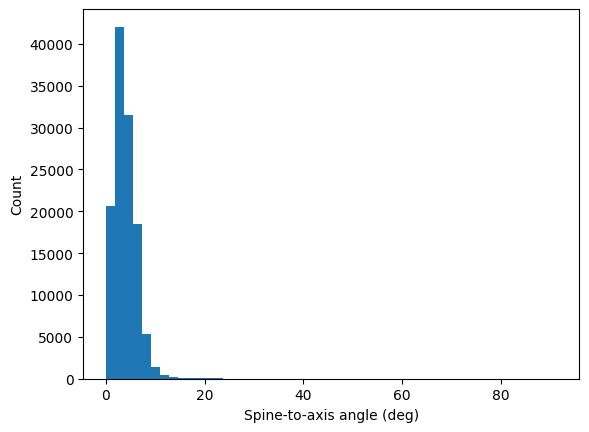

In [31]:
import matplotlib.pyplot as plt
plt.hist(angle_spine_deg[valid_mask].ravel(), bins=50)
plt.xlabel("Spine-to-axis angle (deg)"); plt.ylabel("Count")
plt.show()

In [32]:
mask_c = np.broadcast_to(valid_mask[:, None, :, :], spine_vec.shape)
mean_spine_dir = spine_vec[mask_c].reshape(-1, C).mean(axis=0)
mean_spine_dir /= np.linalg.norm(mean_spine_dir)
print("Empirical average spine direction (x,y,z):", mean_spine_dir)

mean_shoulder_dir = shoulder_vec[mask_c].reshape(-1, C).mean(axis=0)
mean_shoulder_dir /= np.linalg.norm(mean_shoulder_dir)
print("Empirical average shoulder direction (x,y,z):", mean_shoulder_dir)

Empirical average spine direction (x,y,z): [0.57873505 0.5741017  0.57920027]
Empirical average shoulder direction (x,y,z): [0.5883146 0.5788426 0.5646479]


In [33]:
print('TRAINING DATA')
print(f"Total samples: {len(train_data)}")
print(f"Samples per class: {np.bincount(train_labels_np)}")
print('Classes: 0-17')

print('TESTING DATA')
print(f"Total samples: {len(test_data)}")
print(f"Samples per class: {np.bincount(test_labels_np)}")
print('Classes: 0-13, 16')

TRAINING DATA
Total samples: 2452
Samples per class: [ 40  48 175   9 720  21 101 249 724  11  14 167  41  63  11  19  39]
Classes: 0-17
TESTING DATA
Total samples: 610
Samples per class: [ 13   3  15   2  49   1   3 191 243  34   8  30   4   5   0   0   9]
Classes: 0-13, 16


As it can be observed class imbalance is extreme, only classes 4 and 8 account for 64% of the training data
Class 4:  1104 samples  (36% of all data)
Class 8:   880 samples  (28% of all data)
Class 7:   255 samples
Class 11:  190 samples
Class 2:   182 samples
...
Class 3:     9 samples  (0.3%)
Class 14:   11 samples
Class 15:   21 samples

# ST-GCN Model definition 

The first thing we have to do it is to commpute the adjacency matrix. In order to do this we have 3 helper functions:
* build_adjancency: This function builds the adjancency matrix according to the chosen modality; which can be uniform, distance or spatial. These modalities determine the number of subsets in the output matrix, where the uniform mode returns a single shared weight matrix (1 subset), while the distance makes a partition according to the graph distance and finally the spatial one is based on the spatial configuration. 
* normalize: It applies symmetric normalization by performing matrix multiplication D^{-1/2} A D^{-1/2}
* graph_distance: It refers to the Breadth-First Search (BFS), which measures the minimum number of edges needed to reach a node from the 0 node or origin. This information defines how far information propagates, typically each graph convolution layer aggregates from one-hop neighbors, so k layer would capture up to k distance. Consequently, the BFS distance is directly tied to the receptive field of the network.
BFS distance = how many “message-passing steps” are needed for information from a node to influence node

The adjacency matrix is a key concept for this architecture because is telling us which joints are connected (1) and which aren't (0). Indeed, it is a fundamental concept of the ST-GCN architecture because it contains the information about a node and its neighbor. 

In [ ]:
# Helper functions to build the ADJACENCY MATRIX 

# Joint indices (0-indexed) for the standard 25-joint skeleton:
# 0:  base of spine          1:  mid spine
# 2:  neck                   3:  head
# 4:  left shoulder          5:  left elbow
# 6:  left wrist             7:  left hand
# 8:  right shoulder         9:  right elbow
# 10: right wrist            11: right hand
# 12: left hip               13: left knee
# 14: left ankle             15: left foot
# 16: right hip              17: right knee
# 18: right ankle            19: right foot
# 20: spine                  21: tip of left hand
# 22: left thumb             23: tip of right hand
# 24: right thumb

EDGE_LIST = [
    (0, 1), (1, 20), (20, 2), (2, 3),          # spine + head
    (20, 4), (4, 5), (5, 6), (6, 7),            # left arm
    (7, 21), (7, 22),                            # left hand tips
    (20, 8), (8, 9), (9, 10), (10, 11),         # right arm
    (11, 23), (11, 24),                          # right hand tips
    (0, 12), (12, 13), (13, 14), (14, 15),      # left leg
    (0, 16), (16, 17), (17, 18), (18, 19),      # right leg
]


def build_adjacency(num_joints: int, edges: list, strategy: str = "spatial") -> torch.Tensor:
    """
    Build the adjacency matrix A used in ST-GCN.

    Strategies
    ----------
    'uniform'   – single shared weight matrix (original paper variant 1)
    'distance'  – partition by graph distance (variant 2)
    'spatial'   – partition by spatial configuration, root/centripetal/centrifugal
                  (variant 3, default – best results in the original paper)

    Returns
    -------
    A : torch.Tensor of shape (K, V, V)
    K = number of adjacency subsets (1, 2, or 3 depending on strategy)
    """
    V = num_joints
    A_raw = np.zeros((V, V)) #square matrix according to the number of joints
    for i, j in edges:
        A_raw[i, j] = 1 #assigns values of 1 to all cells
        A_raw[j, i] = 1
    np.fill_diagonal(A_raw, 1)  # self-connections

    if strategy == "uniform":
        # K = 1: all neighbours share one weight matrix
        A = _normalize(A_raw)[None]          # (1, V, V)

    elif strategy == "distance":
        # K = 2: self-connections vs. neighbours
        A_self = np.eye(V)
        A_neigh = A_raw - A_self
        A = np.stack([_normalize(A_self), _normalize(A_neigh)])   # (2, V, V)

    else:  # "spatial" – 3-subset partition recommended for skeleton actions
        # Root: equidistant from centre-of-gravity
        # Centripetal: closer to CoG than neighbour
        # Centrifugal: farther  from CoG than neighbour
        A_root = np.eye(V)
        A_close = np.zeros((V, V))
        A_far   = np.zeros((V, V))

        # Simple heuristic: use graph distance from joint 0 as "distance to CoG"
        dist_from_root = _graph_distance(A_raw, V)

        for i in range(V):
            for j in range(V):
                if A_raw[i, j] == 0 or i == j:
                    continue
                if dist_from_root[j] == dist_from_root[i]:
                    A_root[i, j] = 1
                elif dist_from_root[j] < dist_from_root[i]:
                    A_close[i, j] = 1
                else:
                    A_far[i, j] = 1

        A = np.stack([_normalize(A_root),
                      _normalize(A_close),
                      _normalize(A_far)])    # (3, V, V)

    return torch.tensor(A, dtype=torch.float32)


def _normalize(A: np.ndarray) -> np.ndarray:
    """Symmetric normalisation: D^{-1/2} A D^{-1/2}"""
    D = np.diag(A.sum(axis=1).clip(min=1e-6) ** -0.5)
    return D @ A @ D


def _graph_distance(A: np.ndarray, V: int) -> np.ndarray:
    """BFS shortest-path distance from node 0."""
    dist = np.full(V, np.inf)
    dist[0] = 0
    queue = [0]
    while queue:
        node = queue.pop(0)
        for j in range(V):
            if A[node, j] > 0 and dist[j] == np.inf:
                dist[j] = dist[node] + 1
                queue.append(j)
    return dist

A = build_adjacency(num_joints=25, edges=EDGE_LIST, strategy = "spatial")
print('Spatial setting:', A.shape)

The second part is composed by the building blocks, specificaly the Graph Convolution, the Temporal Convolution and the Spatio-Temporal Graph Convolution block.
* GraphConv: Here,a learnable mask is defined, this mask will add a weight to the relationship between nodes. The key part of the graph convolution operation relies on the **x_agg = torch.einsum("nctv, kvw -> knctw", x, A)** line, where we are gathering info from neighbors. For every single joint v at every single frame in time t, it looks at all of its neighboring joints w defined by the matrix A. It multiplies those neighbors' features by the connection strength and it sums them all up. Later, it reshapes the tensor to (N, K*C, T, V) and finally applies a 1×1 conv, which acts like a linear layer applied to every joint at every timeframe. It mixes that gathere neihbor information together and outputs the new feature representation. Note: K will be 3 since we are using the "spatial" configuration to obtain the Adjacency matrix, so 3 subsets are created.
* TemporalConv: This convolution operates in the time axis using a 1D kernel. The stride and padding can be used to modify the tensor's dimensions.
* STGCNBlock: It stacks together the graph and temporal convolution sequentially to form the Spatio-Temporal Graph Convolution Block of the network, before the final ReLU activation is applied, a residual term is added to the output. The residual term acts as a shortcut that prevents the vanishing gradient problem and handles 3 cases.
    1. When the dimensions match perfectly: It multiplies by the identity matrix, which is equivalent to do nothing
    2. Dimensions changed: It applies a 1x1 convolution to fix the tensor dimensions so they can match the puput from the temporal convolution.
    3. Residual disabled: Residual is set to 0, so we are forced to rely 100% on the main path.

In [ ]:
# 2.  BUILDING BLOCKS

class GraphConv(nn.Module):
    """
    Spatial graph convolution.
    Implements: Z = sum_k  A_k  X  W_k
    where the einsum fuses the adjacency multiplication with the learnable weight.
    """

    def __init__(self, in_channels: int, out_channels: int, A: torch.Tensor):
        super().__init__()
        self.K = A.shape[0]        # number of adjacency subsets
        self.register_buffer("A", A)   # (K, V, V) — not a learnable param

        # Learnable importance mask (optional, from the paper)
        self.mask = nn.Parameter(torch.ones_like(A) * 1e-6)

        self.W = nn.Conv2d(in_channels * self.K, out_channels, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (N, C, T, V)
        returns (N, out_channels, T, V)
        """
        A = self.A + self.mask                      # (K, V, V)
        # Aggregate over neighbours for each subset k
        # x_agg[k] = x @ A[k]  →  (N, C, T, V)
        x_agg = torch.einsum("nctv, kvw -> knctw", x, A)   # (K, N, C, T, V)
        N, C, T, V = x.shape
        # Reshape to (N, K*C, T, V) then apply 1×1 conv
        x_agg = x_agg.permute(1, 0, 2, 3, 4).contiguous().view(N, self.K * C, T, V)
        return self.bn(self.W(x_agg))


class TemporalConv(nn.Module):
    """
    Temporal convolution with optional stride for downsampling.
    Operates on the time axis with a 1D kernel across the (T) dimension.
    """

    def __init__(self, channels: int, kernel_size: int = 9, stride: int = 1, dropout: float = 0.5):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.net = nn.Sequential(
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Conv2d(channels, channels,
                      kernel_size=(kernel_size, 1),
                      stride=(stride, 1),
                      padding=(padding, 0)),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class STGCNBlock(nn.Module):
    """
    One ST-GCN block: spatial graph conv → temporal conv → residual.

      ┌── GraphConv ──► ReLU ──► TemporalConv ──┐
      x ──────────────────────────────────────── + ──► ReLU ──► out
      └──── (optional 1×1 residual projection) ──┘
    """

    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 A: torch.Tensor,
                 stride: int = 1,
                 residual: bool = True,
                 dropout: float = 0.5):
        super().__init__()
        self.gcn = GraphConv(in_channels, out_channels, A)
        self.tcn = TemporalConv(out_channels, stride=stride, dropout=dropout)
        self.relu = nn.ReLU(inplace=True)

        if not residual:
            self.res = lambda x: 0
        elif in_channels == out_channels and stride == 1:
            self.res = nn.Identity()
        else:
            self.res = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.relu(self.tcn(self.gcn(x)) + self.res(x))

**ST-GCN for skeleton-based gesture classification.**

Architecture (mirrors the original paper, adapted for SMG):

* Input normalisation BN
* 9 ST-GCN blocks (channels: 64→64→64→128→128→128→256→256→256)
  – Blocks 4 and 7 stride the temporal axis by 2
* Global average pooling over (T, V)
* Fully connected classifier

Original model can be found on the author's github: https://github.com/mikecheninoulu/SMG/tree/main

@article{chen2023smg,
  title={SMG: A Micro-gesture Dataset Towards Spontaneous Body Gestures for Emotional Stress State Analysis},
  author={Chen, Haoyu and Shi, Henglin and Liu, Xin and Li, Xiaobai and Zhao, Guoying},
  journal={International Journal of Computer Vision},
  volume={131},
  number={6},
  pages={1346--1366},
  year={2023},
  publisher={Springer US New York}
}

In [ ]:
# 3.  FULL ST-GCN MODEL

class STGCN(nn.Module):
    """
    Args
    ----
    num_class  : number of gesture classes
    in_channels: input feature channels (3 for x, y, z)
    num_joints : number of skeleton joints (25)
    num_frames : temporal length (90), zero-padding was applied at the end of the sequence 
    num_persons: number of persons tracked simultaneously (1)
    graph_strategy: 'uniform' | 'distance' | 'spatial'
    dropout    : dropout rate in temporal conv layers
    """

    def __init__(self,
                 num_class: int,
                 in_channels: int = 3,
                 num_joints: int = 25,
                 num_frames: int = 90,
                 num_persons: int = 1,
                 graph_strategy: str = "spatial",
                 dropout: float = 0.5):
        super().__init__()

        self.num_persons = num_persons

        # Build graph adjacency
        A = build_adjacency(num_joints, EDGE_LIST, strategy=graph_strategy)
        self.register_buffer("A", A)

        # Input batch normalisation (normalise per channel across the whole graph)
        self.data_bn = nn.BatchNorm1d(in_channels * num_joints * num_persons)

        # ── ST-GCN layers ──────────────────────────────────────────────────
        #  (in_ch, out_ch, stride, residual)
        layer_cfg = [
            (in_channels,  64, 1, False),
            (64,           64, 1, True),
            (64,           64, 1, True),
            (64,          128, 2, True),   # ← temporal stride
            (128,         128, 1, True),
            (128,         128, 1, True),
            (128,         256, 2, True),   # ← temporal stride
            (256,         256, 1, True),
            (256,         256, 1, True),
        ]

        self.layers = nn.ModuleList([
            STGCNBlock(ic, oc, A, stride=s, residual=r, dropout=dropout)
            for ic, oc, s, r in layer_cfg
        ])

        # ── Classifier head ───────────────────────────────────────────────
        self.pool = nn.AdaptiveAvgPool2d(1)   # (N, C, T, V) → (N, C, 1, 1)
        self.classifier = nn.Linear(256, num_class)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (N, C, T, V, M)
        returns logits : (N, num_class)
        """
        N, C, T, V, M = x.shape
        assert M == self.num_persons, f"Expected M={self.num_persons} persons, got {M}"

        # Merge persons into the batch and normalise 
        # (N, C, T, V, M) → (N, M, V, C, T) → (N*M, V*C, T)
        x = x.permute(0, 4, 3, 1, 2).contiguous()   # (N, M, V, C, T)
        x = x.view(N * M, V * C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T)
        x = x.permute(0, 1, 3, 4, 2).contiguous()   # (N, M, C, T, V)
        x = x.view(N * M, C, T, V)

        # ST-GCN blocks 
        for layer in self.layers:
            x = layer(x)

        # Aggregate persons 
        # (N*M, 256, T', V) → (N, M, 256)
        x = self.pool(x)                             # (N*M, 256, 1, 1)
        x = x.view(N, M, -1)
        x = x.mean(dim=1)                            # (N, 256)

        return self.classifier(x)                    # (N, num_class)


# ─────────────────────────────────────────────────────────────────────────────
# 4.  QUICK SANITY CHECK
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    NUM_CLASS = 17         # number of gesture classes

    model = STGCN(num_class=NUM_CLASS, graph_strategy="spatial")
    model.eval()

    dummy = torch.randn(4, 3, 90, 25, 1)   # (N, C, T, V, M)
    with torch.no_grad():
        logits = model(dummy)

    print(f"Input  shape : {dummy.shape}")
    print(f"Output shape : {logits.shape}")   # should be (4, NUM_CLASS)
    print(f"Num params   : {sum(p.numel() for p in model.parameters()):,}")

# MODEL ORIGINAL VERSION
Code obtained from Github: https://github.com/mikecheninoulu/SMG

In [8]:
from stgcn_utils import ConvTemporalGraphical
from stgcn_utils import Graph
from stgcn_utils import st_gcn

class Model_STGCN(nn.Module):
    """Spatial temporal graph convolutional networks.

    Args:
        in_channels (int): Number of channels in the input data
        num_class (int): Number of classes for the classification task
        graph_args (dict): The arguments for building the graph
        edge_importance_weighting (bool): If ``True``, adds a learnable
            importance weighting to the edges of the graph
        **kwargs (optional): Other parameters for graph convolution units

    Shape:
        - Input: :math:`(N, in_channels, T_{in}, V_{in}, M_{in})`
        - Output: :math:`(N, num_class)` where
            :math:`N` is a batch size,
            :math:`T_{in}` is a length of input sequence,
            :math:`V_{in}` is the number of graph nodes,
            :math:`M_{in}` is the number of instance in a frame.
    """

    def __init__(self, in_channels, num_class, graph_args,
                 edge_importance_weighting =True, **kwargs):
        super().__init__()

        # load graph
        self.graph = Graph(**graph_args)
        A = torch.tensor(self.graph.A, dtype=torch.float32, requires_grad=False)
        self.register_buffer('A', A)

        # build networks
        spatial_kernel_size = A.size(0)
        temporal_kernel_size = 9
        kernel_size = (temporal_kernel_size, spatial_kernel_size)
        self.data_bn = nn.BatchNorm1d(in_channels * A.size(1))
        kwargs0 = {k: v for k, v in kwargs.items() if k != 'dropout'}
        self.st_gcn_networks = nn.ModuleList((
            st_gcn(in_channels, 64, kernel_size, 1, residual=False, **kwargs0),
            st_gcn(64, 64, kernel_size, 1, **kwargs),
            st_gcn(64, 64, kernel_size, 1, **kwargs),
            st_gcn(64, 64, kernel_size, 1, **kwargs),
            st_gcn(64, 128, kernel_size, 2, **kwargs),
            st_gcn(128, 128, kernel_size, 1, **kwargs),
            st_gcn(128, 128, kernel_size, 1, **kwargs),
            st_gcn(128, 256, kernel_size, 2, **kwargs),
            st_gcn(256, 256, kernel_size, 1, **kwargs),
            st_gcn(256, 256, kernel_size, 1, **kwargs),
        ))

        # initialize parameters for edge importance weighting
        if edge_importance_weighting:
            self.edge_importance = nn.ParameterList([
                nn.Parameter(torch.ones(self.A.size()))
                for i in self.st_gcn_networks
            ])
        else:
            self.edge_importance = [1] * len(self.st_gcn_networks)

        # fcn for prediction
        self.fcn = nn.Conv2d(256, num_class, kernel_size=1)

    def forward(self, x):

        # data normalization
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous()
        x = x.view(N * M, V * C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T)
        x = x.permute(0, 1, 3, 4, 2).contiguous()
        x = x.view(N * M, C, T, V)

        # forwad
        for gcn, importance in zip(self.st_gcn_networks, self.edge_importance):
            x, _ = gcn(x, self.A * importance)

        # global pooling
        x = F.avg_pool2d(x, x.size()[2:])
        x = x.view(N, M, -1, 1, 1).mean(dim=1)

        # prediction
        x = self.fcn(x)
        x = x.view(x.size(0), -1)

        return x

    def extract_feature(self, x):

        # data normalization
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous()
        x = x.view(N * M, V * C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T)
        x = x.permute(0, 1, 3, 4, 2).contiguous()
        x = x.view(N * M, C, T, V)

        # forwad
        for gcn, importance in zip(self.st_gcn_networks, self.edge_importance):
            x, _ = gcn(x, self.A * importance)

        _, c, t, v = x.size()
        feature = x.view(N, M, c, t, v).permute(0, 2, 3, 4, 1)

        # prediction
        x = self.fcn(x)
        output = x.view(N, M, -1, t, v).permute(0, 2, 3, 4, 1)

        return output, feature

Spatial setting: torch.Size([3, 25, 25])


In [9]:
#TESTING GRAPH FROM UTILS ---------------------------------------------
A = Graph(layout='ntu-rgb+d', strategy='uniform', max_hop=1, dilation=1)
adj_matrix = A.A
adj_matrix = torch.from_numpy(adj_matrix)
print('Uniform setting:', adj_matrix.shape)

A = Graph(layout='ntu-rgb+d', strategy='distance', max_hop=1, dilation=1)
adj_matrix = A.A
print('Distance setting:', adj_matrix.shape)

A = Graph(layout='ntu-rgb+d', strategy='spatial', max_hop=1, dilation=1)
adj_matrix = A.A
adj_matrix = torch.from_numpy(adj_matrix)
print('Spatial setting:', adj_matrix.shape)

#TESTING THE BASIC CONVOLUTIONAL BLOCK -------------------------------
#takes as input the kernel size and the input and output channels
conv_block = ConvTemporalGraphical(in_channels=3, out_channels=64,
                                         kernel_size=3)          

dummy = torch.randn(4, 3, 90, 25)   # (N, C, T, V)

#conv_block(dummy, adj_matrix)


#TESTING THE MODEL ----------------------------------------------------
#This operation returns the new extracted features in the x tensor and the
#unchanged adjacency matrix
if __name__ == "__main__":
    NUM_CLASS = 17         # ← set to your actual number of gesture classes
    graph_args = {'layout':'ntu-rgb+d', 'strategy':'spatial', 'max_hop':1, 'dilation':1}
    model = Model_STGCN(in_channels=3, num_class=NUM_CLASS, graph_args=graph_args, edge_importance_weighting=True)
    model.eval()

    dummy = torch.randn(4, 3, 90, 25, 1)   # (N, C, T, V, M)
    with torch.no_grad():
        logits = model(dummy)

    print(f"Input  shape : {dummy.shape}")
    print(f"Output shape : {logits.shape}")   # should be (4, NUM_CLASS)
    print(f"Num params   : {sum(p.numel() for p in model.parameters()):,}")

Uniform setting: torch.Size([1, 25, 25])
Distance setting: (2, 25, 25)
Spatial setting: torch.Size([3, 25, 25])
Input  shape : torch.Size([4, 3, 90, 25, 1])
Output shape : torch.Size([4, 17])
Num params   : 3,087,781


# MS-G3D Model definition

Code obtained from Github: https://github.com/kenziyuliu/MS-G3D/blob/master/model/msg3d.py

In [ ]:
sys.path.insert(0, '')

from msg3d_utils import AdjMatrixGraph, UnfoldTemporalWindows, SpatialTemporal_MS_GCN
from msg3d_utils import MLP, activation_factory, count_params
from msg3d_utils import MultiScale_GraphConv as MS_GCN
from msg3d_utils import MultiScale_TemporalConv as MS_TCN

class MS_G3D(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 A_binary,
                 num_scales,
                 window_size,
                 window_stride,
                 window_dilation,
                 embed_factor=1,
                 activation='relu'):
        super().__init__()
        self.window_size = window_size
        self.out_channels = out_channels
        self.embed_channels_in = self.embed_channels_out = out_channels // embed_factor
        if embed_factor == 1:
            self.in1x1 = nn.Identity()
            self.embed_channels_in = self.embed_channels_out = in_channels
            # The first STGC block changes channels right away; others change at collapse
            if in_channels == 3:
                self.embed_channels_out = out_channels
        else:
            self.in1x1 = MLP(in_channels, [self.embed_channels_in])

        self.gcn3d = nn.Sequential(
            UnfoldTemporalWindows(window_size, window_stride, window_dilation),
            SpatialTemporal_MS_GCN(
                in_channels=self.embed_channels_in,
                out_channels=self.embed_channels_out,
                A_binary=A_binary,
                num_scales=num_scales,
                window_size=window_size,
                use_Ares=True
            )
        )

        self.out_conv = nn.Conv3d(self.embed_channels_out, out_channels, kernel_size=(1, self.window_size, 1))
        self.out_bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        N, _, T, V = x.shape
        x = self.in1x1(x)
        # Construct temporal windows and apply MS-GCN
        x = self.gcn3d(x)

        # Collapse the window dimension
        x = x.view(N, self.embed_channels_out, -1, self.window_size, V)
        x = self.out_conv(x).squeeze(dim=3)
        x = self.out_bn(x)

        # no activation
        return x


class MultiWindow_MS_G3D(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 A_binary,
                 num_scales,
                 window_sizes=[3,5],
                 window_stride=1,
                 window_dilations=[1,1]):

        super().__init__()
        self.gcn3d = nn.ModuleList([
            MS_G3D(
                in_channels,
                out_channels,
                A_binary,
                num_scales,
                window_size,
                window_stride,
                window_dilation
            )
            for window_size, window_dilation in zip(window_sizes, window_dilations)
        ])

    def forward(self, x):
        # Input shape: (N, C, T, V)
        out_sum = 0
        for gcn3d in self.gcn3d:
            out_sum += gcn3d(x)
        # no activation
        return out_sum


class Model_MSG3D(nn.Module):
    def __init__(self,
                 num_class,
                 num_point,
                 num_person,
                 num_gcn_scales,
                 num_g3d_scales,
                 graph,
                 in_channels=3):
        super(Model_MSG3D, self).__init__()

        # Graph = import_class(graph)
        # A_binary = Graph().A_binary

        Graph = AdjMatrixGraph()
        A_binary = Graph.A_binary

        self.data_bn = nn.BatchNorm1d(num_person * in_channels * num_point)

        # channels
        c1 = 96
        c2 = c1 * 2     # 192
        c3 = c2 * 2     # 384

        # r=3 STGC blocks
        self.gcn3d1 = MultiWindow_MS_G3D(3, c1, A_binary, num_g3d_scales, window_stride=1)
        self.sgcn1 = nn.Sequential(
            MS_GCN(num_gcn_scales, 3, c1, A_binary, disentangled_agg=True),
            MS_TCN(c1, c1),
            MS_TCN(c1, c1))
        self.sgcn1[-1].act = nn.Identity()
        self.tcn1 = MS_TCN(c1, c1)

        self.gcn3d2 = MultiWindow_MS_G3D(c1, c2, A_binary, num_g3d_scales, window_stride=2)
        self.sgcn2 = nn.Sequential(
            MS_GCN(num_gcn_scales, c1, c1, A_binary, disentangled_agg=True),
            MS_TCN(c1, c2, stride=2),
            MS_TCN(c2, c2))
        self.sgcn2[-1].act = nn.Identity()
        self.tcn2 = MS_TCN(c2, c2)

        self.gcn3d3 = MultiWindow_MS_G3D(c2, c3, A_binary, num_g3d_scales, window_stride=2)
        self.sgcn3 = nn.Sequential(
            MS_GCN(num_gcn_scales, c2, c2, A_binary, disentangled_agg=True),
            MS_TCN(c2, c3, stride=2),
            MS_TCN(c3, c3))
        self.sgcn3[-1].act = nn.Identity()
        self.tcn3 = MS_TCN(c3, c3)

        self.fc = nn.Linear(c3, num_class)

    def forward(self, x):
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 3, 1, 2).contiguous().view(N, M * V * C, T)
        x = self.data_bn(x)
        x = x.view(N * M, V, C, T).permute(0,2,3,1).contiguous()

        # Apply activation to the sum of the pathways
        x = F.relu(self.sgcn1(x) + self.gcn3d1(x), inplace=True)
        x = self.tcn1(x)

        x = F.relu(self.sgcn2(x) + self.gcn3d2(x), inplace=True)
        x = self.tcn2(x)

        x = F.relu(self.sgcn3(x) + self.gcn3d3(x), inplace=True)
        x = self.tcn3(x)

        out = x
        out_channels = out.size(1)
        out = out.view(N, M, out_channels, -1)
        out = out.mean(3)   # Global Average Pooling (Spatial+Temporal)
        out = out.mean(1)   # Average pool number of bodies in the sequence

        out = self.fc(out)
        return out


if __name__ == "__main__":
    # For debugging purposes
    import sys
    sys.path.append('..')

    model = Model_MSG3D(
        num_class=17,
        num_point=25,
        num_person=1,
        num_gcn_scales=13,
        num_g3d_scales=6,
        graph='graph.ntu_rgb_d.AdjMatrixGraph'
    )

    N, C, T, V, M = 6, 3, 90, 25, 1
    x = torch.randn(N,C,T,V,M)
    model.forward(x)

    print('Model total # params:', count_params(model))

# Training 

Loss functions for imbalanced gesture classification (SMG dataset):
  - Class-frequency weighted cross-entropy
  - Focal loss (Lin et al., 2017)
  - Combined weighted focal loss
  - Helper: compute_class_weights() from a label array or pkl file

In [8]:
# Class weight computation
def compute_class_weights(labels: np.ndarray, mode: str,
                           num_classes: int = 17,
                           device: torch.device = device) -> torch.Tensor | None:
    """
    mode:
      "none"    → no weighting (returns None → plain CE)
      "sqrt"    → sqrt of inverse frequency  (recommended)
      "inverse" → raw inverse frequency      (aggressive)
    """
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1)                     # avoid div-by-zero
    weights = counts.sum() / (num_classes * counts)    # inverse freq
 
    if mode == "sqrt":
        weights = np.sqrt(weights)
 
    weights = weights / weights.sum()
    return torch.tensor(weights, dtype=torch.float32, device=device)


# Focal loss
class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017) for multi-class classification.

    Focal loss down-weights easy examples so the model focuses on hard,
    misclassified ones — particularly useful when dominant classes are
    "easy" for the model to predict correctly.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Parameters
    ----------
    gamma        : focusing parameter. 0 = standard CE. 2 is the canonical
                   default; try 1–3. Higher = stronger focus on hard examples.
    alpha        : per-class weights tensor of shape (C,), or None.
                   When combined with class_weights, alpha handles imbalance
                   and gamma handles hard example mining separately.
    reduction    : 'mean' | 'sum' | 'none'
    """

    def __init__(
        self,
        gamma: float = 2.0,
        alpha: torch.Tensor | None = None,
        reduction: str = "mean",
    ):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        if alpha is not None:
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        logits  : (N, C) — raw unnormalized scores.
        targets : (N,)   — integer class indices, 0-indexed.
        """
        # Standard CE (per-sample, no reduction yet)
        ce_loss = F.cross_entropy(logits, targets, reduction="none")   # (N,)

        # p_t = probability assigned to the correct class
        log_pt = -ce_loss                          # log(p_t)
        pt = torch.exp(log_pt)                     # p_t ∈ (0, 1]

        # Focusing factor
        focal_weight = (1.0 - pt) ** self.gamma   # (N,)

        # Per-class alpha weighting
        if self.alpha is not None:
            alpha_t = self.alpha[targets]          # (N,)
            focal_weight = alpha_t * focal_weight

        loss = focal_weight * ce_loss              # (N,)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss   # "none"


#  Combined weighted focal loss 
class WeightedFocalLoss(nn.Module):
    """
    Focal loss with class-frequency weighting — the recommended default for
    the SMG dataset given its severe imbalance (classes 4 & 8 account for
    ~64% of samples).

    Combines:
      - Inverse-frequency alpha  → corrects class prior imbalance
      - Focal gamma              → further suppresses easy majority examples
      - Optional label smoothing → reduces overconfidence on noisy labels

    Parameters
    ----------
    class_weights   : float tensor (C,) from compute_class_weights().
    gamma           : focal focusing parameter (default 2.0).
    label_smoothing : float in [0, 1), applied before focal weighting.
    reduction       : 'mean' | 'sum' | 'none'
    """

    def __init__(
        self,
        class_weights: torch.Tensor,
        gamma: float = 2.0,
        label_smoothing: float = 0.0,
        reduction: str = "mean",
    ):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction
        self.register_buffer("class_weights", class_weights)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        num_classes = logits.size(1)

        # --- Label smoothing (manual, so we can keep per-sample CE) ---
        if self.label_smoothing > 0:
            smooth = self.label_smoothing / num_classes
            # Soft targets: one-hot + uniform smoothing
            with torch.no_grad():
                soft_targets = torch.full_like(logits, smooth)
                soft_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing + smooth)
            log_prob = F.log_softmax(logits, dim=1)                    # (N, C)
            ce_loss = -(soft_targets * log_prob).sum(dim=1)            # (N,)
            # p_t from hard targets for the focal term
            with torch.no_grad():
                pt = F.softmax(logits, dim=1).gather(1, targets.unsqueeze(1)).squeeze(1)
        else:
            ce_loss = F.cross_entropy(logits, targets, reduction="none")  # (N,)
            with torch.no_grad():
                pt = torch.exp(-ce_loss)                                   # (N,)

        # Focal weighting
        focal_weight = (1.0 - pt) ** self.gamma                           # (N,)

        # Class (alpha) weighting
        alpha_t = self.class_weights[targets]                              # (N,)

        loss = alpha_t * focal_weight * ce_loss                            # (N,)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

In [62]:
SEARCH_SPACE = {
    # ---- Loss function -------------------------------------------------------
    "loss_type": ["weighted_ce", "focal", "weighted_focal"],
 
    # ---- Loss hyperparameters -----------------------------------------------
    "focal_gamma":       [0.5, 1.0, 2.0],   # ignored for weighted_ce
    "label_smoothing":   [0.0, 0.1],
 
    # ---- Class weight scheme ------------------------------------------------
    "weight_mode":       ["none", "sqrt", "inverse"],
 
    # ---- Sampler ------------------------------------------------------------
    "use_sampler":       [True, False],
 
    # ---- Optimizer ----------------------------------------------------------
    "optimizer":         ["adamw", "sgd"],
    "lr":                [1e-3, 5e-4],
    "weight_decay":      [1e-4, 1e-3],
 
    # ---- Scheduler ----------------------------------------------------------
    "scheduler":         ["cosine", "step", "none"],
 
    # ---- Training duration --------------------------------------------------
    "epochs":            [50],              # fixed — change if needed
    "batch_size":        [32, 64],
}

SMALL_SEARCH_SPACE = {
    # ---- Loss function -------------------------------------------------------
    "loss_type": ["weighted_ce", "focal", "weighted_focal"],
 
    # ---- Loss hyperparameters -----------------------------------------------
    "focal_gamma":       [0.5, 1.0, 2.0],   # ignored for weighted_ce
    "label_smoothing":   [0.0, 0.1],
 
    # ---- Class weight scheme ------------------------------------------------
    "weight_mode":       ["none", "sqrt"],
 
    # ---- Sampler ------------------------------------------------------------
    "use_sampler":       [True, False],
 
    # ---- Training duration --------------------------------------------------
    "epochs":            [15]              # fixed — change if needed
}

# TRADITIONAL TRAINING

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#   TRAINING UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

class EarlyStopping:
    def __init__(self, patience: int = 20, min_delta: float = 1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.best      = np.inf
        self.counter   = 0
        self.triggered = False

    def step(self, val_loss: float) -> bool:
        if val_loss < self.best - self.min_delta:
            self.best    = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
        return self.triggered

class EarlyStoppingAccuracy:
    def __init__(self, patience: int = 20, min_delta: float = 1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.best      = -np.inf  # Start at negative infinity for maximization
        self.counter   = 0
        self.triggered = False

    def step(self, val_acc: float) -> bool:
        # Check if accuracy improved by at least min_delta
        if val_acc > self.best + self.min_delta:
            self.best    = val_acc
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
        return self.triggered


def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        if scaler is not None:   # AMP
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss   = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss   = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, test=False):
    model.eval()
    y_preds=[]
    y_all=[]
    total_loss, correct, total, correct_top5, correct_top3 = 0.0, 0, 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        y_preds.append(logits.argmax(1))
        y_all.append(y)
        loss   = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)

        #top 5 accuracy
        _, top5_idx = torch.topk(logits, 5) #obtain idx of top5 logits 
        top5_idx = top5_idx.t()
        # Check if the target matches any of the top 5 predictions
        correct_5 = top5_idx.eq(y.view(1, -1).expand_as(top5_idx))
        # Sum correct predictions and divide by batch size
        correct_top5 += correct_5[:5].reshape(-1).float().sum(0, keepdim=True).item()
        correct_top3 += correct_5[:3].reshape(-1).float().sum(0, keepdim=True).item()

    # Move tensors to CPU and convert to NumPy before passing to sklearn
    y_all_np = torch.cat(y_preds).cpu().numpy()
    y_preds_np = torch.cat(y_all).cpu().numpy()
    macro_f1 = f1_score(y_all_np, y_preds_np, average='macro')
    
    if test:
        labels = np.arange(0, 17)
        # final_preds = torch.cat(y_preds).cpu().numpy()
        # final_labels = torch.cat(y_all).cpu().numpy()
        #cm = confusion_matrix(final_labels, final_preds, labels=labels)
        cm = confusion_matrix(y_all_np, y_preds_np, labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
                                      #display_labels=clf.classes_)
        disp.plot(cmap=plt.cm.Blues)
        plt.show()
        return total_loss / total, correct / total, y_preds_np, y_all_np, correct_top3 / total, correct_top5 / total, macro_f1
    
    return total_loss / total, correct / total, macro_f1

In [16]:
"""
Training pipeline for ST-GCN on the SMG gesture dataset.
"""
#  MAIN TRAINING SCRIPT

def main(CFG, model, train_ds, val_ds, test_ds, criterion, optimizer, scheduler, sampler=False): 
    #Solving class imbalance using a weighted focal loss, and a random sampler 
    #Compute classes frequency to calculate the weights per class
    model.to(device)
    
    set_seeds(42)
 
    # Seeded generator, shared by every loader that shuffles or samples
    g = torch.Generator()
    g.manual_seed(42) 

    sampler = make_weighted_sampler(train_labels_np)

    val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=g)
    test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=g)
    if sampler==False:
        train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                                  shuffle=True,  num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=g)#, sampler=sampler)
    else:
        train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                                  shuffle=False,  num_workers=4, pin_memory=True, sampler=sampler, worker_init_fn=seed_worker, generator=g)

    
    # ── Loss: label smoothing helps on small datasets ─────────────────────
    stopper   = EarlyStoppingAccuracy(patience=CFG["patience"])
    scaler    = torch.cuda.amp.GradScaler() if CFG["use_amp"] and device.type == "cuda" else None

    # ── Training loop ─────────────────────────────────────────────────────
    best_val_acc = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1":[]}

    for epoch in range(1, CFG["epochs"] + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
        vl_loss, vl_acc, vl_f1 = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)

        if scheduler:
            scheduler.step()

        elapsed = time.time() - t0
        print(f"[{epoch:03d}/{CFG['epochs']}] "
              f"train_loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"val_loss={vl_loss:.4f} acc={vl_acc:.3f} | "
              f"val_f1={vl_f1:.4f} |"
              f"{elapsed:.1f}s")

        # Save best checkpoint
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save({
                "epoch"     : epoch,
                "state_dict": model.state_dict(),
                "optimizer" : optimizer.state_dict(),
                "val_acc"   : vl_acc,
                "config"    : CFG,
            }, CFG["checkpoint"])
            print(f"  ✓ checkpoint saved (val_acc={vl_acc:.3f})")

        if stopper.step(vl_acc):
            print(f"Early stopping at epoch {epoch}")
            break

    # ── Test evaluation ───────────────────────────────────────────────────
    ckpt = torch.load(CFG["checkpoint"], map_location=device)
    model.load_state_dict(ckpt["state_dict"])
    test_loss, test_acc, y_preds, y_all, acc_top3, acc_top5, test_f1 = evaluate(model, test_loader, criterion, device, test=True) #when test=True the conf matrix is performed
    print(f"\nTest accuracy : {test_acc:.4f}  (loss={test_loss:.4f})")
    print(f"Top 3 accuracy : {acc_top3:.4f}")
    print(f"Top 5 accuracy : {acc_top5:.4f}")
    print(f"Macro F1: {test_f1:.4f}")
    print(f"Best val acc  : {best_val_acc:.4f}")

    return history, y_preds, y_all

In [65]:
#Original set up as in the paper
# ── Config ────────────────────────────────────────────────────────────
CFG = dict(
    num_class   = 17,                # number of gesture classes
    # Model
    in_channels = 3,
    graph_strategy = "spatial",
    dropout        = 0.1,
    graph_args = {'layout':'ntu-rgb+d', 'strategy':'spatial', 'max_hop':1, 'dilation':1},
    edge_importance_weighting = True,
    # Training
    epochs      = 30,
    batch_size  = 64,
    lr          = 1e-3,          #0.0005
    weight_decay= 1e-4,          #0.0005
    patience    = 10,            # early stopping
    use_amp     = True,          # automatic mixed precision (GPU only)
    gamma       = 2,                   #weighted local foss
    label_smoothing = 0.1,
    # Misc
    seed        = 42,
    checkpoint  = "best_stgcn.pt",
)

model = Model_STGCN(CFG['in_channels'], 
              CFG['num_class'],
              CFG['graph_args'],
              CFG['edge_importance_weighting']
             ).to(device)

#class_weights = compute_class_weights(train_labels_np, mode="sqrt", num_classes=CFG['num_class'], device=device)
criterion = nn.CrossEntropyLoss() #build_criterion(cfg, class_weights) # #nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-6)

# if __name__ == "__main__":
#     history, y_preds, y_all = main(CFG, model, train_ds, val_ds, test_ds, criterion, optimizer, scheduler)

In [66]:
import kagglehub

# Download latest version
path = kagglehub.model_download("dandrade05/stgcn/pyTorch/default")

print("Path to model files:", path)

Path to model files: /kaggle/input/models/dandrade05/stgcn/pytorch/default/1


In [67]:
model = STGCN(num_class=NUM_CLASS, graph_strategy="spatial")
model_path = "/kaggle/input/models/dandrade05/stgcn/pytorch/default/1/best_stgcn.pt"


# 2. Load the checkpoint dictionary
checkpoint = torch.load(model_path) # Use map_location if loading on a different device

# 3. Load the weights into your model
model.load_state_dict(checkpoint["state_dict"])

# 4. Set the model to evaluation mode
model.eval()

# (Optional) Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

STGCN(
  (data_bn): BatchNorm1d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): ModuleList(
    (0): STGCNBlock(
      (gcn): GraphConv(
        (W): Conv2d(9, 64, kernel_size=(1, 1), stride=(1, 1))
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (tcn): TemporalConv(
        (net): Sequential(
          (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU(inplace=True)
          (2): Dropout(p=0.5, inplace=False)
          (3): Conv2d(64, 64, kernel_size=(9, 1), stride=(1, 1), padding=(4, 0))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (relu): ReLU(inplace=True)
    )
    (1-2): 2 x STGCNBlock(
      (gcn): GraphConv(
        (W): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

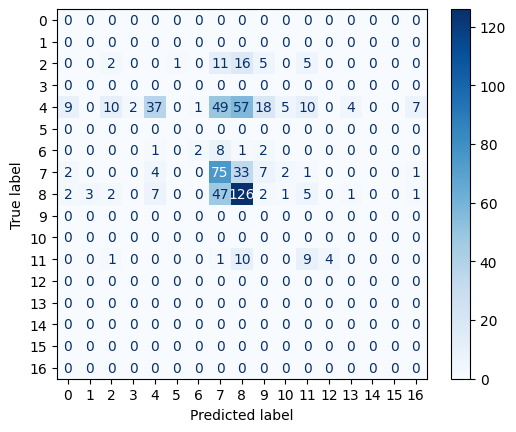


Test accuracy : 0.4115  (loss=2.0652)
Top 3 accuracy : 0.7180
Top 5 accuracy : 0.7984
Macro F1: 0.1313


In [68]:
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"],
                              shuffle=False, num_workers=4, pin_memory=True)
test_loss, test_acc, y_preds, y_all, acc_top3, acc_top5, test_f1 = evaluate(model, test_loader, criterion, device, test=True) #when test=True the conf matrix is performed
print(f"\nTest accuracy : {test_acc:.4f}  (loss={test_loss:.4f})")
print(f"Top 3 accuracy : {acc_top3:.4f}")
print(f"Top 5 accuracy : {acc_top5:.4f}")
print(f"Macro F1: {test_f1:.4f}")

/tmp/ipykernel_57/1764228292.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if CFG["use_amp"] and device.type == "cuda" else None
/tmp/ipykernel_57/1102350081.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[001/5] train_loss=2.4316 acc=0.264 | val_loss=2.6278 acc=0.077 | val_f1=0.0877 |32.6s
  ✓ checkpoint saved (val_acc=0.077)


/tmp/ipykernel_57/1102350081.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[002/5] train_loss=1.6860 acc=0.437 | val_loss=2.2824 acc=0.185 | val_f1=0.1275 |32.7s
  ✓ checkpoint saved (val_acc=0.185)


/tmp/ipykernel_57/1102350081.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[003/5] train_loss=1.3833 acc=0.549 | val_loss=2.3951 acc=0.218 | val_f1=0.1284 |31.5s
  ✓ checkpoint saved (val_acc=0.218)


/tmp/ipykernel_57/1102350081.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[004/5] train_loss=1.2265 acc=0.591 | val_loss=2.2948 acc=0.170 | val_f1=0.1045 |32.3s


/tmp/ipykernel_57/1102350081.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[005/5] train_loss=1.0434 acc=0.661 | val_loss=1.9934 acc=0.261 | val_f1=0.1171 |32.0s
  ✓ checkpoint saved (val_acc=0.261)


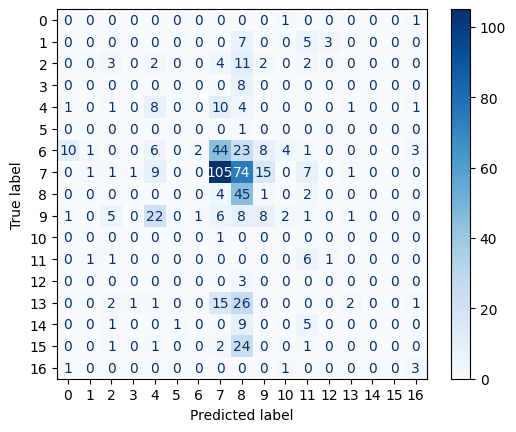


Test accuracy : 0.2984  (loss=2.2246)
Top 3 accuracy : 0.6656
Top 5 accuracy : 0.7885
Macro F1: 0.1306
Best val acc  : 0.2606


In [86]:
CFG = dict(
    num_class   = 17,                # ← set to your actual class count
    # Model
    in_channels = 3,
    graph_strategy = "spatial",
    dropout        = 0.1,
    graph_args = {'layout':'ntu-rgb+d', 'strategy':'spatial', 'max_hop':1, 'dilation':1},
    edge_importance_weighting = True,
    # Training
    epochs      = 30,
    batch_size  = 64,
    lr          = 1e-3,          #0.05
    weight_decay= 1e-4,          #0.0005
    patience    = 10,            # early stopping
    use_amp     = True,          # automatic mixed precision (GPU only)
    gamma       =2,                   #weighted local foss
    label_smoothing=0.1,
    # Misc
    seed        = 42,
    checkpoint  = "best_msg3d.pt",
)

model = Model_MSG3D(
        num_class=17,
        num_point=25,
        num_person=1,
        num_gcn_scales=13,
        num_g3d_scales=6,
        graph='graph.ntu_rgb_d.AdjMatrixGraph'
    ).to(device)

# class_weights = compute_class_weights(train_labels_np, mode = "sqrt", num_classes=CFG['num_class'], device=device)
criterion = nn.CrossEntropyLoss() #nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-6)

if __name__ == "__main__":
     history, y_preds, y_all = main(CFG, model, train_ds, val_ds, test_ds, criterion, optimizer, scheduler, sampler=True)

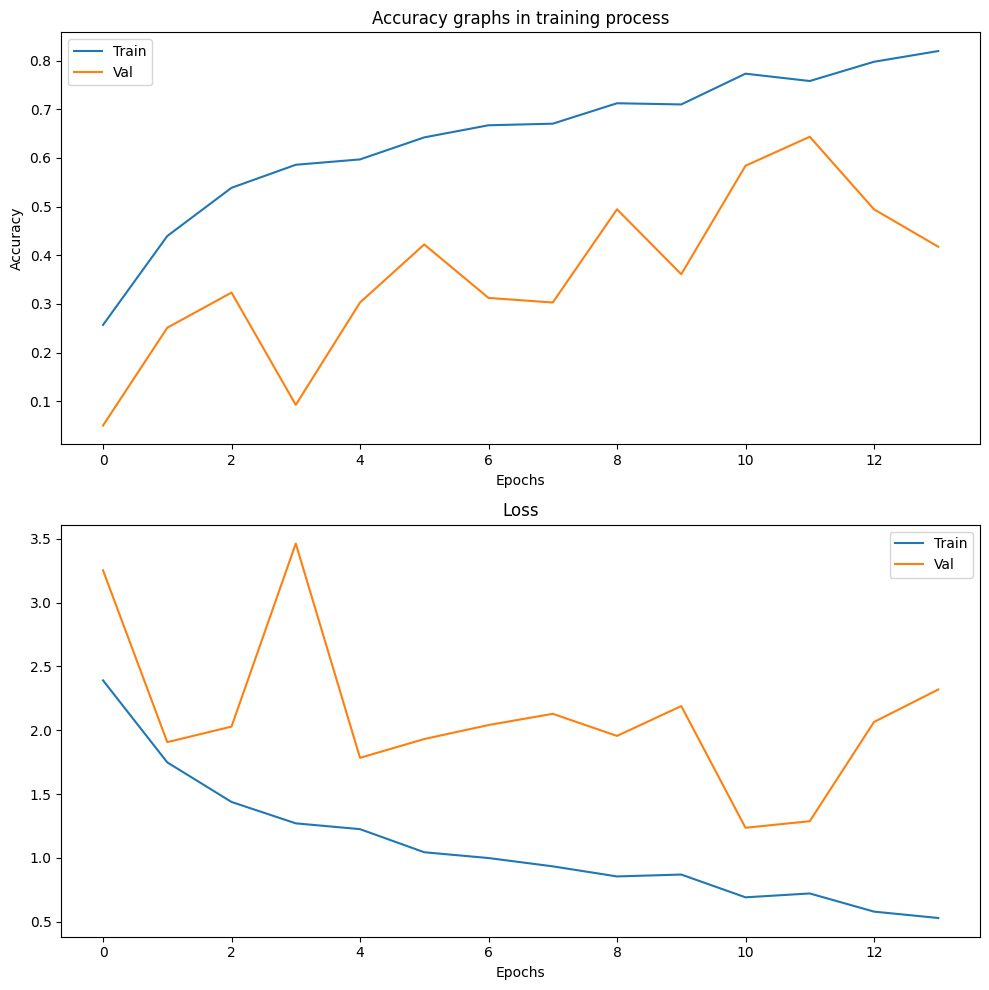

In [82]:
def print_graphsCV(history):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    #for metrics in history.items():
    ax1.plot(history['train_acc'], label=f'Train')
    ax1.plot(history['val_acc'], label=f'Val')
    ax1.set_title(f'Accuracy graphs in training process')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    ax2.plot(history['train_loss'], label=f'Train')
    ax2.plot(history['val_loss'], label=f'Val')
    ax2.set_title(f'Loss')
    ax2.set_xlabel('Epochs')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

print_graphsCV(history)

# CLONING ST-GCN GITHUB

Since the previous results were deviating from the metrics reported by the authors for the ST-GCN model, I decided to directly clone their githubs in order to stick as much as possible to their metrics 

In [10]:
#Cloning github repository
!git clone https://github.com/mikecheninoulu/SMG.git
%cd SMG/classification/SMG/1_st-gcn_smg

Cloning into 'SMG'...
remote: Enumerating objects: 330, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 330 (delta 28), reused 129 (delta 18), pack-reused 175 (from 1)
Receiving objects: 100% (330/330), 44.07 MiB | 11.86 MiB/s, done.
Resolving deltas: 100% (67/67), done.
/kaggle/working/SMG/classification/SMG/1_st-gcn_smg


In [11]:
#Copying datasets into github's directory
!cp /kaggle/input/datasets/dandrade05/smg-dataset/train_data.npy /kaggle/working/SMG/classification/SMG/1_st-gcn_smg/data/SMGskeleton/
!cp /kaggle/input/datasets/dandrade05/smg-dataset/train_label.pkl /kaggle/working/SMG/classification/SMG/1_st-gcn_smg/data/SMGskeleton/

In [12]:
#Positioning inside the 1_st-gcn_smg file and installing libraries  
%cd /kaggle/working/SMG/classification/SMG/1_st-gcn_smg
!pip install -r requirements.txt
%cd torchlight
!python setup.py install

/kaggle/working/SMG/classification/SMG/1_st-gcn_smg
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 37.0 MB/s eta 0:00:00a 0:00:01
/kaggle/working/SMG/classification/SMG/1_st-gcn_smg/torchlight
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        **************************************************

In [14]:
#Reviewing current position
%cd ..

/kaggle/working/SMG/classification/SMG/1_st-gcn_smg


In [13]:
#Setting up a seed for experiments
file_path = '/kaggle/working/SMG/classification/SMG/1_st-gcn_smg/main.py'

with open(file_path, 'r') as f:
    code = f.read()

# Code to inject right at the very beginning of main.py
seed_code = """import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

import os
set_seed(42)
"""

# Inject right after the standard imports if not already there
if "set_seed" not in code:
    # Adding it at the absolute top of the file
    code = seed_code + "\n" + code
    with open(file_path, 'w') as f:
        f.write(code)
    print("Successfully added global random seeds to main.py!")
else:
    print("Seeds are already configured in main.py.")

Successfully added global random seeds to main.py!


In [15]:
file_path = "/kaggle/working/SMG/classification/SMG/1_st-gcn_smg/net/utils/graph.py"

with open(file_path, "r") as f:
    content = f.read()

old_block = """elif layout == 'ntu-rgb+d':
            self.num_node = 25
            self_link = [(i, i) for i in range(self.num_node)]
            neighbor_1base = [(8, 1), (1, 2), (2, 3), (3, 4), (1, 5), (5, 6), (6, 7), (1, 0), (0, 15), (0, 16), (4, 5), (7, 2), (4, 15), (7, 15), (4, 7), (4, 2), (7, 5), (4, 6), (7, 3), (2, 15), (5, 16)]
            neighbor_link = [(i - 1, j - 1) for (i, j) in neighbor_1base]
            self.edge = self_link + neighbor_link
            self.center = 1"""

new_block = """elif layout == 'ntu-rgb+d':
            self.num_node = 25
            self_link = [(i, i) for i in range(self.num_node)]

            # Bone connections using 0-based joint indexing
            neighbor_link = [
                (0, 1), (1, 20), (20, 2), (2, 3),          # spine + head
                (20, 4), (4, 5), (5, 6), (6, 7),            # left arm
                (7, 21), (7, 22),                            # left hand tips
                (20, 8), (8, 9), (9, 10), (10, 11),         # right arm
                (11, 23), (11, 24),                          # right hand tips
                (0, 12), (12, 13), (13, 14), (14, 15),      # left leg
                (0, 16), (16, 17), (17, 18), (18, 19),      # right leg
            ]

            self.edge = self_link + neighbor_link
            self.center = 1"""

if old_block not in content:
    raise ValueError("The original NTU-RGB+D block was not found.")

content = content.replace(old_block, new_block)

with open(file_path, "w") as f:
    f.write(content)

print("graph.py successfully updated.")

graph.py successfully updated.


In [15]:
#Training locally
#! python main.py recognition -c config/st_gcn/smg/train.yaml

[07.17.26|13:23:01] Parameters:
{'work_dir': './work_dir/recognition/smg/ST_GCN', 'config': 'config/st_gcn/smg/train.yaml', 'phase': 'train', 'save_result': False, 'start_epoch': 0, 'num_epoch': 20, 'use_gpu': True, 'device': [0], 'log_interval': 100, 'save_interval': 10, 'eval_interval': 1, 'save_log': True, 'print_log': True, 'pavi_log': False, 'feeder': 'feeder.feeder.Feeder', 'num_worker': 4, 'train_feeder_args': {'data_path': './data/SMGskeleton/train_data.npy', 'label_path': './data/SMGskeleton/train_label.pkl', 'debug': False}, 'test_feeder_args': {'data_path': './data/SMGskeleton/test_data.npy', 'label_path': './data/SMGskeleton/test_label.pkl'}, 'batch_size': 64, 'test_batch_size': 64, 'debug': False, 'model': 'net.st_gcn.Model', 'model_args': {'in_channels': 3, 'num_class': 17, 'dropout': 0.1, 'edge_importance_weighting': True, 'graph_args': {'layout': 'ntu-rgb+d', 'strategy': 'spatial'}}, 'weights': None, 'ignore_weights': [], 'show_topk': [1, 5], 'base_lr': 0.01, 'step': [5

In [10]:
%cd ..

/kaggle/working/SMG/classification/SMG/1_st-gcn_smg


In [19]:
#Training with personalized parameters
! python main.py recognition -c config/st_gcn/smg/train.yaml --batch_size 64 --num_epoch 30 --weight_decay 0.0001 --base_lr 0.01 

[08.18.26|19:52:15] Parameters:
{'work_dir': './work_dir/recognition/smg/ST_GCN', 'config': 'config/st_gcn/smg/train.yaml', 'phase': 'train', 'save_result': False, 'start_epoch': 0, 'num_epoch': 30, 'use_gpu': True, 'device': [0], 'log_interval': 100, 'save_interval': 10, 'eval_interval': 1, 'save_log': True, 'print_log': True, 'pavi_log': False, 'feeder': 'feeder.feeder.Feeder', 'num_worker': 4, 'train_feeder_args': {'data_path': './data/SMGskeleton/train_data.npy', 'label_path': './data/SMGskeleton/train_label.pkl', 'debug': False}, 'test_feeder_args': {'data_path': './data/SMGskeleton/test_data.npy', 'label_path': './data/SMGskeleton/test_label.pkl'}, 'batch_size': 64, 'test_batch_size': 64, 'debug': False, 'model': 'net.st_gcn.Model', 'model_args': {'in_channels': 3, 'num_class': 17, 'dropout': 0.1, 'edge_importance_weighting': True, 'graph_args': {'layout': 'ntu-rgb+d', 'strategy': 'spatial'}}, 'weights': None, 'ignore_weights': [], 'show_topk': [1, 5], 'base_lr': 0.01, 'step': [5

In [20]:
#Checking current position
!pwd

/kaggle/working/SMG/classification/SMG/1_st-gcn_smg


In [21]:
#Reviewing files inside working directory
!ls -lh /kaggle/working/SMG/classification/SMG/1_st-gcn_smg/work_dir/recognition/smg/ST_GCN

total 36M
-rw-r--r-- 1 root root 1.1K Aug 18 19:52 config.yaml
-rw-r--r-- 1 root root  12M Aug 18 19:57 epoch10_model.pt
-rw-r--r-- 1 root root  12M Aug 18 20:02 epoch20_model.pt
-rw-r--r-- 1 root root  12M Aug 18 20:07 epoch30_model.pt
-rw-r--r-- 1 root root  13K Aug 18 20:07 log.txt


In [22]:
# Path to your test configuration file
yaml_path = '/kaggle/working/SMG/classification/SMG/1_st-gcn_smg/config/st_gcn/smg/test.yaml'

# 1. Read the current contents of the file
with open(yaml_path, 'r') as file:
    content = file.read()

# 2. Replace the 'SMGskeletonB' path with your actual 'SMGskeleton' path
updated_content = content.replace('./data/SMGskeletonB/test_data.npy', './data/SMGskeleton/test_data.npy')

# 3. Write the corrected content back to the file
with open(yaml_path, 'w') as file:
    file.write(updated_content)

print("Successfully updated test.yaml!")

Successfully updated test.yaml!


In [23]:
#Confirming updated path inside feeder
!cat /kaggle/working/SMG/classification/SMG/1_st-gcn_smg/config/st_gcn/smg/test.yaml

weights: ./work_dir/recognition/mg/ST_GCN/epoch10_model.pt

# feeder
feeder: feeder.feeder.Feeder
test_feeder_args:
  data_path: ./data/SMGskeleton/test_data.npy
  label_path: ./data/SMGskeleton/test_label.pkl

# model
model: net.st_gcn.Model
model_args:
  in_channels: 3
  num_class: 17
  dropout: 0.1
  edge_importance_weighting: True
  graph_args:
    layout: 'ntu-rgb+d'
    strategy: 'spatial'

# test 
phase: test
device: 0
test_batch_size: 64



In [24]:
#Testing model
! python main.py recognition -c config/st_gcn/smg/test.yaml --weights /kaggle/working/SMG/classification/SMG/1_st-gcn_smg/work_dir/recognition/smg/ST_GCN/epoch30_model.pt

[08.18.26|20:10:19] Load weights from /kaggle/working/SMG/classification/SMG/1_st-gcn_smg/work_dir/recognition/smg/ST_GCN/epoch30_model.pt.
[08.18.26|20:10:19] Load weights [A].
[08.18.26|20:10:19] Load weights [data_bn.weight].
[08.18.26|20:10:19] Load weights [data_bn.bias].
[08.18.26|20:10:19] Load weights [data_bn.running_mean].
[08.18.26|20:10:19] Load weights [data_bn.running_var].
[08.18.26|20:10:19] Load weights [data_bn.num_batches_tracked].
[08.18.26|20:10:19] Load weights [st_gcn_networks.0.gcn.conv.weight].
[08.18.26|20:10:19] Load weights [st_gcn_networks.0.gcn.conv.bias].
[08.18.26|20:10:19] Load weights [st_gcn_networks.0.tcn.0.weight].
[08.18.26|20:10:19] Load weights [st_gcn_networks.0.tcn.0.bias].
[08.18.26|20:10:19] Load weights [st_gcn_networks.0.tcn.0.running_mean].
[08.18.26|20:10:19] Load weights [st_gcn_networks.0.tcn.0.running_var].
[08.18.26|20:10:19] Load weights [st_gcn_networks.0.tcn.0.num_batches_tracked].
[08.18.26|20:10:19] Load weights [st_gcn_networks.

In [26]:
#Including confusion matrix inside test function of REC_Processor

file_path = '/kaggle/working/SMG/classification/SMG/1_st-gcn_smg/processor/recognition.py'

# 1. Read the current contents of recognition.py
with open(file_path, 'r') as f:
    code = f.read()

# 2. Define the old target lines where we want to insert our code
# We target the loop that shows the top-k accuracy right at the end of the test function
old_target = """            # show top-k accuracy
            for k in self.arg.show_topk:
                self.show_topk(k)"""

# 3. Define what we want that section to look like after adding the confusion matrix
new_target = """            # show top-k accuracy
            for k in self.arg.show_topk:
                self.show_topk(k)

            # === ADDED: CONFUSION MATRIX GENERATION ===
            try:
                import matplotlib.pyplot as plt
                import seaborn as sns
                from sklearn.metrics import confusion_matrix
                
                # Get the top-1 predictions from the concatenated output scores
                all_preds = np.argmax(self.result, axis=1)
                all_labels = self.label  # Ground truth labels concatenated above
                
                # Force 17 classes (0 through 16) even if some do not appear in the test split
                target_labels = list(range(17))
                cm = confusion_matrix(all_labels, all_preds, labels=target_labels)
                class_names = [str(i) for i in target_labels]
                
                # Plotting using the exact visual specs you provided
                plt.figure(figsize=(10, 8))
                sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", 
                            xticklabels=class_names, yticklabels=class_names)
                
                plt.title('Confusion Matrix (Raw Counts)')
                plt.ylabel('True label')
                plt.xlabel('Predicted label')
                plt.tight_layout()
                
                # Save it cleanly to the working directory
                save_path = '/kaggle/working/confusion_matrix.png'
                plt.savefig(save_path, dpi=300)
                print(f"Confusion Matrix saved successfully to: {save_path}")
                plt.close() # Close plot to clear memory
                
            except Exception as e:
                print(f"Warning: Could not generate confusion matrix due to error: {e}")
            # =========================================="""

# 4. Perform the replacement and rewrite the file
if old_target in code:
    code = code.replace(old_target, new_target)
    with open(file_path, 'w') as f:
        f.write(code)
    print("Successfully updated recognition.py with the confusion matrix code!")
else:
    print("Error: Could not find the target code block in recognition.py. Double-check your file content.")

Successfully updated recognition.py with the confusion matrix code!


In [25]:
#Copying model weights inside folder 
!cp /kaggle/input/models/dandrade05/st-gcn-weights-20/pytorch/default/1/epoch20_model.pt /kaggle/working/SMG/classification/SMG/1_st-gcn_smg/work_dir/recognition/smg/ST_GCN

In [27]:
! python main.py recognition -c config/st_gcn/smg/test.yaml --weights /kaggle/working/SMG/classification/SMG/1_st-gcn_smg/work_dir/recognition/smg/ST_GCN/epoch30_model.pt

[08.18.26|20:18:34] Load weights from /kaggle/working/SMG/classification/SMG/1_st-gcn_smg/work_dir/recognition/smg/ST_GCN/epoch30_model.pt.
[08.18.26|20:18:34] Load weights [A].
[08.18.26|20:18:34] Load weights [data_bn.weight].
[08.18.26|20:18:34] Load weights [data_bn.bias].
[08.18.26|20:18:34] Load weights [data_bn.running_mean].
[08.18.26|20:18:34] Load weights [data_bn.running_var].
[08.18.26|20:18:34] Load weights [data_bn.num_batches_tracked].
[08.18.26|20:18:34] Load weights [st_gcn_networks.0.gcn.conv.weight].
[08.18.26|20:18:34] Load weights [st_gcn_networks.0.gcn.conv.bias].
[08.18.26|20:18:34] Load weights [st_gcn_networks.0.tcn.0.weight].
[08.18.26|20:18:34] Load weights [st_gcn_networks.0.tcn.0.bias].
[08.18.26|20:18:34] Load weights [st_gcn_networks.0.tcn.0.running_mean].
[08.18.26|20:18:34] Load weights [st_gcn_networks.0.tcn.0.running_var].
[08.18.26|20:18:34] Load weights [st_gcn_networks.0.tcn.0.num_batches_tracked].
[08.18.26|20:18:34] Load weights [st_gcn_networks.

# CLONING MS-G3D

In [17]:
!pip install tensorboardX

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 2.2 MB/s eta 0:00:00a 0:00:01


In [5]:
!git clone https://github.com/kenziyuliu/MS-G3D.git

Cloning into 'MS-G3D'...
remote: Enumerating objects: 171, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 171 (delta 56), reused 55 (delta 55), pack-reused 94 (from 1)
Receiving objects: 100% (171/171), 86.72 MiB | 46.27 MiB/s, done.
Resolving deltas: 100% (68/68), done.


In [29]:
# List everything in your current directory
!ls -lh

total 60K
drwxr-xr-x  3 root root 4.0K Jul 17 12:46 config
drwxr-xr-x  3 root root 4.0K Jul 17 12:46 data
drwxr-xr-x  3 root root 4.0K Jul 17 12:46 feeder
-rw-r--r--  1 root root 1.4K Jul 17 13:22 main.py
drwxr-xr-x  3 root root 4.0K Jul 17 12:46 models
drwxr-xr-x 10 root root 4.0K Jul 17 14:06 MS-G3D
drwxr-xr-x  4 root root 4.0K Jul 17 12:46 net
drwxr-xr-x  3 root root 4.0K Jul 17 12:46 processor
-rw-r--r--  1 root root    1 Jul 17 12:46 README
-rw-r--r--  1 root root 3.1K Jul 17 12:46 README.md
-rw-r--r--  1 root root   79 Jul 17 12:46 requirements.txt
drwxr-xr-x  2 root root 4.0K Jul 17 12:46 resource
drwxr-xr-x  4 root root 4.0K Jul 17 12:46 tools
drwxr-xr-x  6 root root 4.0K Jul 17 12:46 torchlight
drwxr-xr-x  4 root root 4.0K Jul 17 12:58 work_dir


In [24]:
#Move repository to /kaggle/working 
!mv /kaggle/working/SMG/classification/SMG/1_st-gcn_smg/MS-G3D /kaggle/working/

In [6]:
#Creating SMG folder inside config folder 
!mkdir -p /kaggle/working/MS-G3D/config/smg
!mkdir -p /kaggle/working/MS-G3D/data/smg

In [30]:
#Copy data files into MS-G3D directory 
!cp /kaggle/input/datasets/dandrade05/smg-splitted-sets/train_data_fixed.npy /kaggle/working/MS-G3D/data/smg
!cp /kaggle/input/datasets/dandrade05/smg-splitted-sets/train_labels_tuple.pkl /kaggle/working/MS-G3D/data/smg
!cp /kaggle/input/datasets/dandrade05/smg-splitted-sets/val_data.npy /kaggle/working/MS-G3D/data/smg
!cp /kaggle/input/datasets/dandrade05/smg-splitted-sets/val_labels_tuple.pkl /kaggle/working/MS-G3D/data/smg
!cp /kaggle/input/datasets/dandrade05/smg-dataset/test_data.npy /kaggle/working/MS-G3D/data/smg
!cp /kaggle/input/datasets/dandrade05/smg-dataset/test_label.pkl /kaggle/working/MS-G3D/data/smg

In [57]:
%%writefile /kaggle/working/MS-G3D/config/smg/train_joint.yaml
work_dir: ./work_dir/smg/msg3d_joint

# feeder
feeder: feeders.feeder.Feeder
train_feeder_args:
  data_path: ./data/smg/train_data_fixed.npy
  label_path: ./data/smg/train_labels_tuple.pkl
  debug: False
  random_choose: False
  random_shift: False
  random_move: False
  window_size: -1
  normalization: False

test_feeder_args:
  data_path: ./data/smg/val_data.npy
  label_path: ./data/smg/val_labels_tuple.pkl

# model
model: model.msg3d.Model
model_args:
  num_class: 17
  num_point: 25
  num_person: 1
  num_gcn_scales: 13    # `num_scales` == `K + 1` in the paper
  num_g3d_scales: 6
  graph: graph.ntu_rgb_d.AdjMatrixGraph

# optim
weight_decay: 0.0005
base_lr: 0.05
step: [10, 20]

# training
num_epoch: 30
device: [0]
batch_size: 32
forward_batch_size: 16
test_batch_size: 32
nesterov: True

Overwriting /kaggle/working/MS-G3D/config/smg/train_joint.yaml


In [33]:
%cd /kaggle/working/MS-G3D

/kaggle/working/MS-G3D


In [35]:
!pwd

/kaggle/working/MS-G3D


In [10]:
%%writefile /kaggle/working/MS-G3D/main.py

#!/usr/bin/env python
from __future__ import print_function
import os
import time
import yaml
import pprint
import random
import pickle
import shutil
import inspect
import argparse
from collections import OrderedDict, defaultdict

import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from tensorboardX import SummaryWriter
from torch.optim.lr_scheduler import MultiStepLR
# import apex  # moved to lazy import below (only needed if --half is used)

from utils import count_params, import_class



def init_seed(seed):
    torch.cuda.manual_seed_all(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)


def get_parser():
    # parameter priority: command line > config file > default
    parser = argparse.ArgumentParser(description='MS-G3D')

    parser.add_argument(
        '--work-dir',
        type=str,
        required=True,
        help='the work folder for storing results')
    parser.add_argument('--model_saved_name', default='')
    parser.add_argument(
        '--config',
        default='./config/nturgbd-cross-view/test_bone.yaml',
        help='path to the configuration file')
    parser.add_argument(
        '--assume-yes',
        action='store_true',
        help='Say yes to every prompt')

    parser.add_argument(
        '--phase',
        default='train',
        help='must be train or test')
    parser.add_argument(
        '--save-score',
        type=str2bool,
        default=False,
        help='if ture, the classification score will be stored')

    parser.add_argument(
        '--seed',
        type=int,
        default=random.randrange(200),
        help='random seed')
    parser.add_argument(
        '--log-interval',
        type=int,
        default=100,
        help='the interval for printing messages (#iteration)')
    parser.add_argument(
        '--save-interval',
        type=int,
        default=1,
        help='the interval for storing models (#iteration)')
    parser.add_argument(
        '--eval-interval',
        type=int,
        default=1,
        help='the interval for evaluating models (#iteration)')
    parser.add_argument(
        '--eval-start',
        type=int,
        default=1,
        help='The epoch number to start evaluating models')
    parser.add_argument(
        '--print-log',
        type=str2bool,
        default=True,
        help='print logging or not')
    parser.add_argument(
        '--show-topk',
        type=int,
        default=[1, 5],
        nargs='+',
        help='which Top K accuracy will be shown')

    parser.add_argument(
        '--feeder',
        default='feeder.feeder',
        help='data loader will be used')
    parser.add_argument(
        '--num-worker',
        type=int,
        default=os.cpu_count(),
        help='the number of worker for data loader')
    parser.add_argument(
        '--train-feeder-args',
        default=dict(),
        help='the arguments of data loader for training')
    parser.add_argument(
        '--test-feeder-args',
        default=dict(),
        help='the arguments of data loader for test')

    parser.add_argument(
        '--model',
        default=None,
        help='the model will be used')
    parser.add_argument(
        '--model-args',
        type=dict,
        default=dict(),
        help='the arguments of model')
    parser.add_argument(
        '--weights',
        default=None,
        help='the weights for network initialization')
    parser.add_argument(
        '--ignore-weights',
        type=str,
        default=[],
        nargs='+',
        help='the name of weights which will be ignored in the initialization')
    parser.add_argument(
        '--half',
        action='store_true',
        help='Use half-precision (FP16) training')
    parser.add_argument(
        '--amp-opt-level',
        type=int,
        default=1,
        help='NVIDIA Apex AMP optimization level')

    parser.add_argument(
        '--base-lr',
        type=float,
        default=0.01,
        help='initial learning rate')
    parser.add_argument(
        '--step',
        type=int,
        default=[20, 40, 60],
        nargs='+',
        help='the epoch where optimizer reduce the learning rate')
    parser.add_argument(
        '--device',
        type=int,
        default=0,
        nargs='+',
        help='the indexes of GPUs for training or testing')
    parser.add_argument(
        '--optimizer',
        default='SGD',
        help='type of optimizer')
    parser.add_argument(
        '--nesterov',
        type=str2bool,
        default=False,
        help='use nesterov or not')
    parser.add_argument(
        '--batch-size',
        type=int,
        default=32,
        help='training batch size')
    parser.add_argument(
        '--test-batch-size',
        type=int,
        default=256,
        help='test batch size')
    parser.add_argument(
        '--forward-batch-size',
        type=int,
        default=16,
        help='Batch size during forward pass, must be factor of --batch-size')
    parser.add_argument(
        '--start-epoch',
        type=int,
        default=0,
        help='start training from which epoch')
    parser.add_argument(
        '--num-epoch',
        type=int,
        default=80,
        help='stop training in which epoch')
    parser.add_argument(
        '--weight-decay',
        type=float,
        default=0.0005,
        help='weight decay for optimizer')
    parser.add_argument(
        '--optimizer-states',
        type=str,
        help='path of previously saved optimizer states')
    parser.add_argument(
        '--checkpoint',
        type=str,
        help='path of previously saved training checkpoint')
    parser.add_argument(
        '--debug',
        type=str2bool,
        default=False,
        help='Debug mode; default false')

    return parser


class Processor():
    """Processor for Skeleton-based Action Recgnition"""

    def __init__(self, arg):
        self.arg = arg
        self.save_arg()
        if arg.phase == 'train':
            # Added control through the command line
            arg.train_feeder_args['debug'] = arg.train_feeder_args['debug'] or self.arg.debug
            logdir = os.path.join(arg.work_dir, 'trainlogs')
            if not arg.train_feeder_args['debug']:
                # logdir = arg.model_saved_name
                if os.path.isdir(logdir):
                    print(f'log_dir {logdir} already exists')
                    if arg.assume_yes:
                        answer = 'y'
                    else:
                        answer = input('delete it? [y]/n:')
                    if answer.lower() in ('y', ''):
                        shutil.rmtree(logdir)
                        print('Dir removed:', logdir)
                    else:
                        print('Dir not removed:', logdir)

                self.train_writer = SummaryWriter(os.path.join(logdir, 'train'), 'train')
                self.val_writer = SummaryWriter(os.path.join(logdir, 'val'), 'val')
            else:
                self.train_writer = SummaryWriter(os.path.join(logdir, 'debug'), 'debug')

        self.load_model()
        self.load_param_groups()
        self.load_optimizer()
        self.load_lr_scheduler()
        self.load_data()

        self.global_step = 0
        self.lr = self.arg.base_lr
        self.best_acc = 0
        self.best_acc_epoch = 0

        if self.arg.half:
            self.print_log('*************************************')
            self.print_log('*** Using Half Precision Training ***')
            self.print_log('*************************************')
            import apex  # only import if --half was actually requested
            self.model, self.optimizer = apex.amp.initialize(
                self.model,
                self.optimizer,
                opt_level=f'O{self.arg.amp_opt_level}'
            )
            if self.arg.amp_opt_level != 1:
                self.print_log('[WARN] nn.DataParallel is not yet supported by amp_opt_level != "O1"')

        if type(self.arg.device) is list:
            if len(self.arg.device) > 1:
                self.print_log(f'{len(self.arg.device)} GPUs available, using DataParallel')
                self.model = nn.DataParallel(
                    self.model,
                    device_ids=self.arg.device,
                    output_device=self.output_device
                )

    def load_model(self):
        output_device = self.arg.device[0] if type(
            self.arg.device) is list else self.arg.device
        self.output_device = output_device
        Model = import_class(self.arg.model)

        # Copy model file and main
        shutil.copy2(inspect.getfile(Model), self.arg.work_dir)
        shutil.copy2(os.path.join('.', __file__), self.arg.work_dir)

        self.model = Model(**self.arg.model_args).cuda(output_device)
        self.loss = nn.CrossEntropyLoss().cuda(output_device)
        self.print_log(f'Model total number of params: {count_params(self.model)}')

        if self.arg.weights:
            try:
                self.global_step = int(self.arg.weights[:-3].split('-')[-1])
            except:
                print('Cannot parse global_step from model weights filename')
                self.global_step = 0

            self.print_log(f'Loading weights from {self.arg.weights}')
            if '.pkl' in self.arg.weights:
                with open(self.arg.weights, 'r') as f:
                    weights = pickle.load(f)
            else:
                weights = torch.load(self.arg.weights)

            weights = OrderedDict(
                [[k.split('module.')[-1],
                  v.cuda(output_device)] for k, v in weights.items()])

            for w in self.arg.ignore_weights:
                if weights.pop(w, None) is not None:
                    self.print_log(f'Sucessfully Remove Weights: {w}')
                else:
                    self.print_log(f'Can Not Remove Weights: {w}')

            try:
                self.model.load_state_dict(weights)
            except:
                state = self.model.state_dict()
                diff = list(set(state.keys()).difference(set(weights.keys())))
                self.print_log('Can not find these weights:')
                for d in diff:
                    self.print_log('  ' + d)
                state.update(weights)
                self.model.load_state_dict(state)

    def load_param_groups(self):
        """
        Template function for setting different learning behaviour
        (e.g. LR, weight decay) of different groups of parameters
        """
        self.param_groups = defaultdict(list)

        for name, params in self.model.named_parameters():
            self.param_groups['other'].append(params)

        self.optim_param_groups = {
            'other': {'params': self.param_groups['other']}
        }

    def load_optimizer(self):
        params = list(self.optim_param_groups.values())
        if self.arg.optimizer == 'SGD':
            self.optimizer = optim.SGD(
                params,
                lr=self.arg.base_lr,
                momentum=0.9,
                nesterov=self.arg.nesterov,
                weight_decay=self.arg.weight_decay)
        elif self.arg.optimizer == 'Adam':
            self.optimizer = optim.Adam(
                params,
                lr=self.arg.base_lr,
                weight_decay=self.arg.weight_decay)
        else:
            raise ValueError('Unsupported optimizer: {}'.format(self.arg.optimizer))

        # Load optimizer states if any
        if self.arg.checkpoint is not None:
            self.print_log(f'Loading optimizer states from: {self.arg.checkpoint}')
            self.optimizer.load_state_dict(torch.load(self.arg.checkpoint)['optimizer_states'])
            current_lr = self.optimizer.param_groups[0]['lr']
            self.print_log(f'Starting LR: {current_lr}')
            self.print_log(f'Starting WD1: {self.optimizer.param_groups[0]["weight_decay"]}')
            if len(self.optimizer.param_groups) >= 2:
                self.print_log(f'Starting WD2: {self.optimizer.param_groups[1]["weight_decay"]}')

    def load_lr_scheduler(self):
        self.lr_scheduler = MultiStepLR(self.optimizer, milestones=self.arg.step, gamma=0.1)
        if self.arg.checkpoint is not None:
            scheduler_states = torch.load(self.arg.checkpoint)['lr_scheduler_states']
            self.print_log(f'Loading LR scheduler states from: {self.arg.checkpoint}')
            self.lr_scheduler.load_state_dict(scheduler_states)
            self.print_log(f'Starting last epoch: {scheduler_states["last_epoch"]}')
            self.print_log(f'Loaded milestones: {scheduler_states["last_epoch"]}')

    def load_data(self):
        Feeder = import_class(self.arg.feeder)
        self.data_loader = dict()

        def worker_seed_fn(worker_id):
            # give workers different seeds
            return init_seed(self.arg.seed + worker_id + 1)

        if self.arg.phase == 'train':
            self.data_loader['train'] = torch.utils.data.DataLoader(
                dataset=Feeder(**self.arg.train_feeder_args),
                batch_size=self.arg.batch_size,
                shuffle=True,
                num_workers=self.arg.num_worker,
                drop_last=True,
                worker_init_fn=worker_seed_fn)

        self.data_loader['test'] = torch.utils.data.DataLoader(
            dataset=Feeder(**self.arg.test_feeder_args),
            batch_size=self.arg.test_batch_size,
            shuffle=False,
            num_workers=self.arg.num_worker,
            drop_last=False,
            worker_init_fn=worker_seed_fn)

    def save_arg(self):
        # save arg
        arg_dict = vars(self.arg)
        if not os.path.exists(self.arg.work_dir):
            os.makedirs(self.arg.work_dir)
        with open(os.path.join(self.arg.work_dir, 'config.yaml'), 'w') as f:
            yaml.dump(arg_dict, f)

    def print_time(self):
        localtime = time.asctime(time.localtime(time.time()))
        self.print_log(f'Local current time: {localtime}')

    def print_log(self, s, print_time=True):
        if print_time:
            localtime = time.asctime(time.localtime(time.time()))
            s = f'[ {localtime} ] {s}'
        print(s)
        if self.arg.print_log:
            with open(os.path.join(self.arg.work_dir, 'log.txt'), 'a') as f:
                print(s, file=f)

    def record_time(self):
        self.cur_time = time.time()
        return self.cur_time

    def split_time(self):
        split_time = time.time() - self.cur_time
        self.record_time()
        return split_time

    def save_states(self, epoch, states, out_folder, out_name):
        out_folder_path = os.path.join(self.arg.work_dir, out_folder)
        out_path = os.path.join(out_folder_path, out_name)
        os.makedirs(out_folder_path, exist_ok=True)
        torch.save(states, out_path)

    def save_checkpoint(self, epoch, out_folder='checkpoints'):
        state_dict = {
            'epoch': epoch,
            'optimizer_states': self.optimizer.state_dict(),
            'lr_scheduler_states': self.lr_scheduler.state_dict(),
        }

        checkpoint_name = f'checkpoint-{epoch}-fwbz{self.arg.forward_batch_size}-{int(self.global_step)}.pt'
        self.save_states(epoch, state_dict, out_folder, checkpoint_name)

    def save_weights(self, epoch, out_folder='weights'):
        state_dict = self.model.state_dict()
        weights = OrderedDict([
            [k.split('module.')[-1], v.cpu()]
            for k, v in state_dict.items()
        ])

        weights_name = f'weights-{epoch}-{int(self.global_step)}.pt'
        self.save_states(epoch, weights, out_folder, weights_name)

    def train(self, epoch, save_model=False):
        self.model.train()
        loader = self.data_loader['train']
        loss_values = []
        self.train_writer.add_scalar('epoch', epoch + 1, self.global_step)
        self.record_time()
        timer = dict(dataloader=0.001, model=0.001, statistics=0.001)

        current_lr = self.optimizer.param_groups[0]['lr']
        self.print_log(f'Training epoch: {epoch + 1}, LR: {current_lr:.4f}')

        process = tqdm(loader, dynamic_ncols=True)
        for batch_idx, (data, label, index) in enumerate(process):
            self.global_step += 1
            # get data
            with torch.no_grad():
                data = data.float().cuda(self.output_device)
                label = label.long().cuda(self.output_device)
            timer['dataloader'] += self.split_time()

            # backward
            self.optimizer.zero_grad()

            ############## Gradient Accumulation for Smaller Batches ##############
            real_batch_size = self.arg.forward_batch_size
            splits = len(data) // real_batch_size
            assert len(data) % real_batch_size == 0, \
                'Real batch size should be a factor of arg.batch_size!'

            for i in range(splits):
                left = i * real_batch_size
                right = left + real_batch_size
                batch_data, batch_label = data[left:right], label[left:right]

                # forward
                output = self.model(batch_data)
                if isinstance(output, tuple):
                    output, l1 = output
                    l1 = l1.mean()
                else:
                    l1 = 0

                loss = self.loss(output, batch_label) / splits

                if self.arg.half:
                    with apex.amp.scale_loss(loss, self.optimizer) as scaled_loss:
                        scaled_loss.backward()
                else:
                    loss.backward()

                loss_values.append(loss.item())
                timer['model'] += self.split_time()

                # Display loss
                process.set_description(f'(BS {real_batch_size}) loss: {loss.item():.4f}')

                value, predict_label = torch.max(output, 1)
                acc = torch.mean((predict_label == batch_label).float())

                self.train_writer.add_scalar('acc', acc, self.global_step)
                self.train_writer.add_scalar('loss', loss.item() * splits, self.global_step)
                self.train_writer.add_scalar('loss_l1', l1, self.global_step)

            #####################################

            # torch.nn.utils.clip_grad_norm_(self.model.parameters(), 2)
            self.optimizer.step()

            # statistics
            self.lr = self.optimizer.param_groups[0]['lr']
            self.train_writer.add_scalar('lr', self.lr, self.global_step)
            timer['statistics'] += self.split_time()

            # Delete output/loss after each batch since it may introduce extra mem during scoping
            # https://discuss.pytorch.org/t/gpu-memory-consumption-increases-while-training/2770/3
            del output
            del loss

        # statistics of time consumption and loss
        proportion = {
            k: f'{int(round(v * 100 / sum(timer.values()))):02d}%'
            for k, v in timer.items()
        }

        mean_loss = np.mean(loss_values)
        num_splits = self.arg.batch_size // self.arg.forward_batch_size
        self.print_log(f'\tMean training loss: {mean_loss:.4f} (BS {self.arg.batch_size}: {mean_loss * num_splits:.4f}).')
        self.print_log('\tTime consumption: [Data]{dataloader}, [Network]{model}'.format(**proportion))

        # PyTorch > 1.2.0: update LR scheduler here with `.step()`
        # and make sure to save the `lr_scheduler.state_dict()` as part of checkpoint
        self.lr_scheduler.step()

        if save_model:
            # save training checkpoint & weights
            self.save_weights(epoch + 1)
            self.save_checkpoint(epoch + 1)

    def eval(self, epoch, save_score=False, loader_name=['test'], wrong_file=None, result_file=None):
        # Skip evaluation if too early
        if epoch + 1 < self.arg.eval_start:
            return

        if wrong_file is not None:
            f_w = open(wrong_file, 'w')
        if result_file is not None:
            f_r = open(result_file, 'w')
        with torch.no_grad():
            self.model = self.model.cuda(self.output_device)
            self.model.eval()
            self.print_log(f'Eval epoch: {epoch + 1}')
            for ln in loader_name:
                loss_values = []
                score_batches = []
                step = 0
                process = tqdm(self.data_loader[ln], dynamic_ncols=True)
                for batch_idx, (data, label, index) in enumerate(process):
                    data = data.float().cuda(self.output_device)
                    label = label.long().cuda(self.output_device)
                    output = self.model(data)
                    if isinstance(output, tuple):
                        output, l1 = output
                        l1 = l1.mean()
                    else:
                        l1 = 0
                    loss = self.loss(output, label)
                    score_batches.append(output.data.cpu().numpy())
                    loss_values.append(loss.item())

                    _, predict_label = torch.max(output.data, 1)
                    step += 1

                    if wrong_file is not None or result_file is not None:
                        predict = list(predict_label.cpu().numpy())
                        true = list(label.data.cpu().numpy())
                        for i, x in enumerate(predict):
                            if result_file is not None:
                                f_r.write(str(x) + ',' + str(true[i]) + '\n')
                            if x != true[i] and wrong_file is not None:
                                f_w.write(str(index[i]) + ',' + str(x) + ',' + str(true[i]) + '\n')

            score = np.concatenate(score_batches)
            loss = np.mean(loss_values)
            accuracy = self.data_loader[ln].dataset.top_k(score, 1)
            if accuracy > self.best_acc:
                self.best_acc = accuracy
                self.best_acc_epoch = epoch + 1

            print('Accuracy: ', accuracy, ' model: ', self.arg.work_dir)
            if self.arg.phase == 'train' and not self.arg.debug:
                self.val_writer.add_scalar('loss', loss, self.global_step)
                self.val_writer.add_scalar('loss_l1', l1, self.global_step)
                self.val_writer.add_scalar('acc', accuracy, self.global_step)

            score_dict = dict(zip(self.data_loader[ln].dataset.sample_name, score))
            self.print_log(f'\tMean {ln} loss of {len(self.data_loader[ln])} batches: {np.mean(loss_values)}.')
            for k in self.arg.show_topk:
                self.print_log(f'\tTop {k}: {100 * self.data_loader[ln].dataset.top_k(score, k):.2f}%')

            if save_score:
                with open('{}/epoch{}_{}_score.pkl'.format(self.arg.work_dir, epoch + 1, ln), 'wb') as f:
                    pickle.dump(score_dict, f)

        # Empty cache after evaluation
        torch.cuda.empty_cache()

    def start(self):
        if self.arg.phase == 'train':
            self.print_log(f'Parameters:\n{pprint.pformat(vars(self.arg))}\n')
            self.print_log(f'Model total number of params: {count_params(self.model)}')
            self.global_step = self.arg.start_epoch * len(self.data_loader['train']) / self.arg.batch_size
            for epoch in range(self.arg.start_epoch, self.arg.num_epoch):
                save_model = ((epoch + 1) % self.arg.save_interval == 0) or (epoch + 1 == self.arg.num_epoch)
                self.train(epoch, save_model=save_model)
                self.eval(epoch, save_score=self.arg.save_score, loader_name=['test'])

            num_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
            self.print_log(f'Best accuracy: {self.best_acc}')
            self.print_log(f'Epoch number: {self.best_acc_epoch}')
            self.print_log(f'Model name: {self.arg.work_dir}')
            self.print_log(f'Model total number of params: {num_params}')
            self.print_log(f'Weight decay: {self.arg.weight_decay}')
            self.print_log(f'Base LR: {self.arg.base_lr}')
            self.print_log(f'Batch Size: {self.arg.batch_size}')
            self.print_log(f'Forward Batch Size: {self.arg.forward_batch_size}')
            self.print_log(f'Test Batch Size: {self.arg.test_batch_size}')

        elif self.arg.phase == 'test':
            if not self.arg.test_feeder_args['debug']:
                wf = os.path.join(self.arg.work_dir, 'wrong-samples.txt')
                rf = os.path.join(self.arg.work_dir, 'right-samples.txt')
            else:
                wf = rf = None
            if self.arg.weights is None:
                raise ValueError('Please appoint --weights.')

            self.print_log(f'Model:   {self.arg.model}')
            self.print_log(f'Weights: {self.arg.weights}')

            self.eval(
                epoch=0,
                save_score=self.arg.save_score,
                loader_name=['test'],
                wrong_file=wf,
                result_file=rf
            )

            self.print_log('Done.\n')


def str2bool(v):
    if v.lower() in ('yes', 'true', 't', 'y', '1'):
        return True
    elif v.lower() in ('no', 'false', 'f', 'n', '0'):
        return False
    else:
        raise argparse.ArgumentTypeError('Boolean value expected.')


def main():
    parser = get_parser()

    # load arg form config file
    p = parser.parse_args()
    if p.config is not None:
        with open(p.config, 'r') as f:
            default_arg = yaml.load(f, Loader=yaml.FullLoader)
        key = vars(p).keys()
        for k in default_arg.keys():
            if k not in key:
                print('WRONG ARG:', k)
                assert (k in key)
        parser.set_defaults(**default_arg)

    arg = parser.parse_args()
    init_seed(arg.seed)
    processor = Processor(arg)
    processor.start()


if __name__ == '__main__':
    main()

Overwriting /kaggle/working/MS-G3D/main.py


In [58]:
!rm -rf ./work_dir/smg/msg3d_joint/trainlogs
!python3 main.py \
  --config /kaggle/working/MS-G3D/config/smg/train_joint.yaml \
  --work-dir ./work_dir/smg/msg3d_joint \
  --device 0 1 \
  --base-lr 0.05 \
  --batch-size 32 \
  --weight-decay 0.0005 \
  --forward-batch-size 32 \
  --eval-start 1

[ Fri Jul 24 15:29:13 2026 ] Model total number of params: 3177890
[ Fri Jul 24 15:29:15 2026 ] 2 GPUs available, using DataParallel
[ Fri Jul 24 15:29:15 2026 ] Parameters:
{'amp_opt_level': 1,
 'assume_yes': False,
 'base_lr': 0.05,
 'batch_size': 32,
 'checkpoint': None,
 'config': '/kaggle/working/MS-G3D/config/smg/train_joint.yaml',
 'debug': False,
 'device': [0, 1],
 'eval_interval': 1,
 'eval_start': 1,
 'feeder': 'feeders.feeder.Feeder',
 'forward_batch_size': 32,
 'half': False,
 'ignore_weights': [],
 'log_interval': 100,
 'model': 'model.msg3d.Model',
 'model_args': {'graph': 'graph.ntu_rgb_d.AdjMatrixGraph',
                'num_class': 17,
                'num_g3d_scales': 6,
                'num_gcn_scales': 13,
                'num_person': 1,
                'num_point': 25},
 'model_saved_name': '',
 'nesterov': True,
 'num_epoch': 30,
 'num_worker': 4,
 'optimizer': 'SGD',
 'optimizer_states': None,
 'phase': 'train',
 'print_log': True,
 'save_interval': 1,
 'save_s

In [59]:
%%writefile /kaggle/working/MS-G3D/config/smg/test_joint.yaml

# feeder
feeder: feeders.feeder.Feeder
test_feeder_args:
  data_path: ./data/smg/test_data.npy
  label_path: ./data/smg/test_label.pkl
  debug: False

# model
model: model.msg3d.Model
model_args:
  num_class: 17
  num_point: 25
  num_person: 1
  num_gcn_scales: 13    # `num_scales` == `K + 1` in the paper
  num_g3d_scales: 6
  graph: graph.ntu_rgb_d.AdjMatrixGraph

# test
phase: test
device: [0]
test_batch_size: 32
weights: ./work_dir/smg/msg3d_joint/weights/weights-30-2280.pt

work_dir: ./work_dir/smg/msg3d_joint/testing
save_score: True

Overwriting /kaggle/working/MS-G3D/config/smg/test_joint.yaml


In [60]:
!python3 main.py \
  --config /kaggle/working/MS-G3D/config/smg/test_joint.yaml \
  --work-dir /kaggle/working/MS-G3D/work_dir/smg/msg3d_joint/testing \
  --weights /kaggle/working/MS-G3D/work_dir/smg/msg3d_joint/weights/weights-30-2280.pt

[ Fri Jul 24 16:01:04 2026 ] Model total number of params: 3177890
[ Fri Jul 24 16:01:04 2026 ] Loading weights from /kaggle/working/MS-G3D/work_dir/smg/msg3d_joint/weights/weights-30-2280.pt
[ Fri Jul 24 16:01:05 2026 ] Model:   model.msg3d.Model
[ Fri Jul 24 16:01:05 2026 ] Weights: /kaggle/working/MS-G3D/work_dir/smg/msg3d_joint/weights/weights-30-2280.pt
[ Fri Jul 24 16:01:05 2026 ] Eval epoch: 1
100%|███████████████████████████████████████████| 20/20 [00:03<00:00,  5.22it/s]
Accuracy:  0.5983606557377049  model:  /kaggle/working/MS-G3D/work_dir/smg/msg3d_joint/testing
[ Fri Jul 24 16:01:09 2026 ] 	Mean test loss of 20 batches: 1.7904014468193055.
[ Fri Jul 24 16:01:09 2026 ] 	Top 1: 59.84%
[ Fri Jul 24 16:01:09 2026 ] 	Top 5: 87.21%
[ Fri Jul 24 16:01:09 2026 ] Done.



In [61]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Load the data (assuming the file is named 'labels.txt')
# We explicitly name the columns based on your format
df = pd.read_csv('/kaggle/working/MS-G3D/work_dir/smg/msg3d_joint/testing/right-samples.txt', header=None, names=['predicted', 'true'])

# 3. Compute the confusion matrix
# Note: sklearn expects (y_true, y_pred)
target_labels = list(range(17))
cm = confusion_matrix(df['true'], df['predicted'], labels=target_labels)

class_names = [str(i) for i in target_labels]

# Plotting using the exact visual specs you provided
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix (Raw Counts)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()

# Save it cleanly to the working directory
save_path = '/kaggle/working/confusion_matrix2.png'
plt.savefig(save_path, dpi=300)
print(f"Confusion Matrix saved successfully to: {save_path}")
plt.close() # Close plot to clear memory

Confusion Matrix saved successfully to: /kaggle/working/confusion_matrix2.png


In [ ]:
#Resume training from epoch 30

python3 main.py
  --config /kaggle/working/MS-G3D/config/smg/train_joint.yaml \
  --work-dir ./work_dir/smg/msg3d_joint \
  --device 0 1 \
  --base-lr 0.05 \
  --batch-size 32 \
  --weight-decay 0.0005 \
  --forward-batch-size 32 \
  --eval-start 1
  --start-epoch 30
  --weights /kaggle/working/MS-G3D/work_dir/smg/msg3d_joint/weights/weights-30-2280.pt
  --checkpoint <checkpoint in work_dir>

# CLONING CTR-GCN

https://github.com/Uason-Chen/CTR-GCN/blob/main/model/ctrgcn.py

In [53]:
!pwd

/kaggle/working


In [52]:
cd /kaggle/working/

/kaggle/working


In [54]:
#Cloning github repository
!git clone https://github.com/Uason-Chen/CTR-GCN

Cloning into 'CTR-GCN'...
remote: Enumerating objects: 202, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 202 (delta 61), reused 48 (delta 48), pack-reused 102 (from 1)
Receiving objects: 100% (202/202), 1.67 MiB | 14.97 MiB/s, done.
Resolving deltas: 100% (78/78), done.


In [55]:
!pip install tensorboardX

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/torchlight-1.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [56]:
#Creating SMG folder inside config folder 
!mkdir -p /kaggle/working/CTR-GCN/config/smg
!mkdir -p /kaggle/working/CTR-GCN/data/smg

In [57]:
!cp /kaggle/input/datasets/dandrade05/smg-splitted-sets/train_data_fixed.npy /kaggle/working/CTR-GCN/data/smg
!cp /kaggle/input/datasets/dandrade05/smg-splitted-sets/train_labels_tuple.pkl /kaggle/working/CTR-GCN/data/smg
!cp /kaggle/input/datasets/dandrade05/smg-splitted-sets/val_data.npy /kaggle/working/CTR-GCN/data/smg
!cp /kaggle/input/datasets/dandrade05/smg-splitted-sets/val_labels_tuple.pkl /kaggle/working/CTR-GCN/data/smg
!cp /kaggle/input/datasets/dandrade05/smg-dataset/test_data.npy /kaggle/working/CTR-GCN/data/smg
!cp /kaggle/input/datasets/dandrade05/smg-dataset/test_label.pkl /kaggle/working/CTR-GCN/data/smg

In [58]:
%%writefile /kaggle/working/CTR-GCN/feeders/legacy_tools.py

import random
import numpy as np


def downsample(data_numpy, step, random_sample=True):
    # input: C,T,V,M
    begin = np.random.randint(step) if random_sample else 0
    return data_numpy[:, begin::step, :, :]


def temporal_slice(data_numpy, step):
    # input: C,T,V,M
    C, T, V, M = data_numpy.shape
    return data_numpy.reshape(C, T / step, step, V, M).transpose(
        (0, 1, 3, 2, 4)).reshape(C, T / step, V, step * M)


def mean_subtractor(data_numpy, mean):
    # input: C,T,V,M
    # naive version
    if mean == 0:
        return
    C, T, V, M = data_numpy.shape
    valid_frame = (data_numpy != 0).sum(axis=3).sum(axis=2).sum(axis=0) > 0
    begin = valid_frame.argmax()
    end = len(valid_frame) - valid_frame[::-1].argmax()
    data_numpy[:, :end, :, :] = data_numpy[:, :end, :, :] - mean
    return data_numpy


def auto_pading(data_numpy, size, random_pad=False):
    C, T, V, M = data_numpy.shape
    if T < size:
        begin = random.randint(0, size - T) if random_pad else 0
        data_numpy_paded = np.zeros((C, size, V, M))
        data_numpy_paded[:, begin:begin + T, :, :] = data_numpy
        return data_numpy_paded
    else:
        return data_numpy


def random_choose(data_numpy, size, auto_pad=True):
    C, T, V, M = data_numpy.shape
    if T == size:
        return data_numpy
    elif T < size:
        if auto_pad:
            return auto_pading(data_numpy, size, random_pad=True)
        else:
            return data_numpy
    else:
        begin = random.randint(0, T - size)
        return data_numpy[:, begin:begin + size, :, :]


def random_move(data_numpy,
                angle_candidate=[-10., -5., 0., 5., 10.],
                scale_candidate=[0.9, 1.0, 1.1],
                transform_candidate=[-0.2, -0.1, 0.0, 0.1, 0.2],
                move_time_candidate=[1]):
    # input: C,T,V,M
    C, T, V, M = data_numpy.shape
    move_time = random.choice(move_time_candidate)
    node = np.arange(0, T, T * 1.0 / move_time).round().astype(int)
    node = np.append(node, T)
    num_node = len(node)

    A = np.random.choice(angle_candidate, num_node)
    S = np.random.choice(scale_candidate, num_node)
    T_x = np.random.choice(transform_candidate, num_node)
    T_y = np.random.choice(transform_candidate, num_node)

    a = np.zeros(T)
    s = np.zeros(T)
    t_x = np.zeros(T)
    t_y = np.zeros(T)

    # linspace
    for i in range(num_node - 1):
        a[node[i]:node[i + 1]] = np.linspace(
            A[i], A[i + 1], node[i + 1] - node[i]) * np.pi / 180
        s[node[i]:node[i + 1]] = np.linspace(S[i], S[i + 1],
                                             node[i + 1] - node[i])
        t_x[node[i]:node[i + 1]] = np.linspace(T_x[i], T_x[i + 1],
                                               node[i + 1] - node[i])
        t_y[node[i]:node[i + 1]] = np.linspace(T_y[i], T_y[i + 1],
                                               node[i + 1] - node[i])

    theta = np.array([[np.cos(a) * s, -np.sin(a) * s],
                      [np.sin(a) * s, np.cos(a) * s]])

    # perform transformation
    for i_frame in range(T):
        xy = data_numpy[0:2, i_frame, :, :]
        new_xy = np.dot(theta[:, :, i_frame], xy.reshape(2, -1))
        new_xy[0] += t_x[i_frame]
        new_xy[1] += t_y[i_frame]
        data_numpy[0:2, i_frame, :, :] = new_xy.reshape(2, V, M)

    return data_numpy


def random_shift(data_numpy):
    C, T, V, M = data_numpy.shape
    data_shift = np.zeros(data_numpy.shape)
    valid_frame = (data_numpy != 0).sum(axis=3).sum(axis=2).sum(axis=0) > 0
    begin = valid_frame.argmax()
    end = len(valid_frame) - valid_frame[::-1].argmax()

    size = end - begin
    bias = random.randint(0, T - size)
    data_shift[:, bias:bias + size, :, :] = data_numpy[:, begin:end, :, :]

    return data_shift


def openpose_match(data_numpy):
    C, T, V, M = data_numpy.shape
    assert (C == 3)
    score = data_numpy[2, :, :, :].sum(axis=1)
    # the rank of body confidence in each frame (shape: T-1, M)
    rank = (-score[0:T - 1]).argsort(axis=1).reshape(T - 1, M)

    # data of frame 1
    xy1 = data_numpy[0:2, 0:T - 1, :, :].reshape(2, T - 1, V, M, 1)
    # data of frame 2
    xy2 = data_numpy[0:2, 1:T, :, :].reshape(2, T - 1, V, 1, M)
    # square of distance between frame 1&2 (shape: T-1, M, M)
    distance = ((xy2 - xy1) ** 2).sum(axis=2).sum(axis=0)

    # match pose
    forward_map = np.zeros((T, M), dtype=int) - 1
    forward_map[0] = range(M)
    for m in range(M):
        choose = (rank == m)
        forward = distance[choose].argmin(axis=1)
        for t in range(T - 1):
            distance[t, :, forward[t]] = np.inf
        forward_map[1:][choose] = forward
    assert (np.all(forward_map >= 0))

    # string data
    for t in range(T - 1):
        forward_map[t + 1] = forward_map[t + 1][forward_map[t]]

    # generate data
    new_data_numpy = np.zeros(data_numpy.shape)
    for t in range(T):
        new_data_numpy[:, t, :, :] = data_numpy[:, t, :, forward_map[
                                                             t]].transpose(1, 2, 0)
    data_numpy = new_data_numpy

    # score sort
    trace_score = data_numpy[2, :, :, :].sum(axis=1).sum(axis=0)
    rank = (-trace_score).argsort()
    data_numpy = data_numpy[:, :, :, rank]

    return data_numpy

Writing /kaggle/working/CTR-GCN/feeders/legacy_tools.py


In [59]:
%%writefile /kaggle/working/CTR-GCN/feeders/feeder_smg.py

import sys
sys.path.extend(['../'])

import pickle
import numpy as np
from torch.utils.data import Dataset

from feeders import legacy_tools as tools  # see note below on this import


class Feeder(Dataset):
    def __init__(self, data_path, label_path,
                 random_choose=False, random_shift=False, random_move=False,
                 window_size=-1, normalization=False, debug=False, use_mmap=True,
                 bone=False, vel=False):
        """
        Feeder for SMG skeleton data, adapted from the MS-G3D-style feeder.
        Compatible with CTR-GCN's training loop (returns data, label, index).

        :param data_path: path to '.npy' data, shape (N, C, T, V, M)
        :param label_path: path to '.pkl' label file, containing (sample_name, label)
        :param random_choose: if True, randomly choose a portion of the input sequence
        :param random_shift: if True, randomly pad zeros at the beginning/end of sequence
        :param random_move: if True, apply random affine motion augmentation
        :param window_size: length of the output sequence (-1 = no resizing)
        :param normalization: if True, normalize input sequence using train-set mean/std
        :param debug: if True, only use the first 100 samples
        :param use_mmap: if True, use mmap mode to load data (saves RAM)
        :param bone: if True, convert joint data to bone data using SMG_PAIRS
        :param vel: if True, convert to motion (frame-to-frame differences)
        """
        self.debug = debug
        self.data_path = data_path
        self.label_path = label_path
        self.random_choose = random_choose
        self.random_shift = random_shift
        self.random_move = random_move
        self.window_size = window_size
        self.normalization = normalization
        self.use_mmap = use_mmap
        self.bone = bone
        self.vel = vel
        self.load_data()
        if normalization:
            self.get_mean_map()

    def load_data(self):
        # data: N C T V M
        try:
            with open(self.label_path) as f:
                self.sample_name, self.label = pickle.load(f)
        except UnicodeDecodeError:
            with open(self.label_path, 'rb') as f:
                self.sample_name, self.label = pickle.load(f, encoding='latin1')

        if self.use_mmap:
            self.data = np.load(self.data_path, mmap_mode='r')
        else:
            self.data = np.load(self.data_path)

        if self.debug:
            self.label = self.label[0:100]
            self.data = self.data[0:100]
            self.sample_name = self.sample_name[0:100]

    def get_mean_map(self):
        data = self.data
        N, C, T, V, M = data.shape
        self.mean_map = data.mean(axis=2, keepdims=True).mean(axis=4, keepdims=True).mean(axis=0)
        self.std_map = data.transpose((0, 2, 4, 1, 3)).reshape((N * T * M, C * V)).std(axis=0).reshape((C, 1, V, 1))

    def __len__(self):
        return len(self.label)

    def __iter__(self):
        return self

    def __getitem__(self, index):
        data_numpy = self.data[index]
        label = self.label[index]
        data_numpy = np.array(data_numpy)

        if self.normalization:
            data_numpy = (data_numpy - self.mean_map) / self.std_map
        if self.random_shift:
            data_numpy = tools.random_shift(data_numpy)
        if self.random_choose:
            data_numpy = tools.random_choose(data_numpy, self.window_size)
        elif self.window_size > 0:
            data_numpy = tools.auto_pading(data_numpy, self.window_size)
        if self.random_move:
            data_numpy = tools.random_move(data_numpy)

        # --- modality conversion, CTR-GCN-style (added, opt-in) ---
        if self.bone:
            from .bone_pairs import smg_pairs  # define this for SMG's joint layout
            bone_data_numpy = np.zeros_like(data_numpy)
            for v1, v2 in smg_pairs:
                bone_data_numpy[:, :, v1 - 1] = data_numpy[:, :, v1 - 1] - data_numpy[:, :, v2 - 1]
            data_numpy = bone_data_numpy

        if self.vel:
            data_numpy[:, :-1] = data_numpy[:, 1:] - data_numpy[:, :-1]
            data_numpy[:, -1] = 0
        # ------------------------------------------------------------

        return data_numpy, label, index

    def top_k(self, score, top_k):
        rank = score.argsort()
        hit_top_k = [l in rank[i, -top_k:] for i, l in enumerate(self.label)]
        return sum(hit_top_k) * 1.0 / len(hit_top_k)

Writing /kaggle/working/CTR-GCN/feeders/feeder_smg.py


In [18]:
%%writefile /kaggle/working/CTR-GCN/config/smg/train_CFR.yaml
work_dir: ./work_dir/smg/ctr-gcn

# feeder
feeder: feeders.feeder_smg.Feeder
train_feeder_args:
  data_path: ./data/smg/train_data_fixed.npy
  label_path: ./data/smg/train_labels_tuple.pkl
  #split: train
  debug: False
  random_choose: False
  random_shift: False
  random_move: False
  window_size: 64
  normalization: False
  #random_rot: True
  #p_interval: [0.5, 1]
  vel: False
  bone: False

test_feeder_args:
  data_path: ./data/smg/val_data.npy
  label_path: ./data/smg/val_labels_tuple.pkl
  #split: test
  window_size: 64
  #p_interval: [0.95]
  vel: False
  bone: False
  debug: False

# model
model: model.ctrgcn.Model
model_args:
  num_class: 17
  num_point: 25
  num_person: 1
  graph: graph.ntu_rgb_d.Graph
  graph_args:
    labeling_mode: 'spatial'

#optim
weight_decay: 0.0005
base_lr: 0.05
lr_decay_rate: 0.1
step: [15, 25]
warm_up_epoch: 5

# training
device: [0 1]
batch_size: 64
test_batch_size: 64
num_epoch: 30
nesterov: True

Overwriting /kaggle/working/CTR-GCN/config/smg/train_CFR.yaml


In [19]:
%cd /kaggle/working/CTR-GCN

/kaggle/working/CTR-GCN


In [20]:
%%writefile /kaggle/working/CTR-GCN/main.py

from __future__ import print_function

import argparse
import inspect
import os
import pickle
import random
import shutil
import sys
import time
from collections import OrderedDict
import traceback
from sklearn.metrics import confusion_matrix
import csv
import numpy as np
import glob

# torch
import torch
import torch.backends.cudnn as cudnn
import torch.nn as nn
import torch.optim as optim
import yaml
from tensorboardX import SummaryWriter
from tqdm import tqdm

#from torchlight import DictAction


import resource
rlimit = resource.getrlimit(resource.RLIMIT_NOFILE)
resource.setrlimit(resource.RLIMIT_NOFILE, (2048, rlimit[1]))

class DictAction(argparse.Action):
    def __init__(self, option_strings, dest, nargs=None, **kwargs):
        if nargs is not None:
            raise ValueError("nargs not allowed")
        super(DictAction, self).__init__(option_strings, dest, **kwargs)

    def __call__(self, parser, namespace, values, option_string=None):
        input_dict = eval('dict({})'.format(values))  # noqa: S307
        output_dict = getattr(namespace, self.dest)
        for k in input_dict:
            output_dict[k] = input_dict[k]
        setattr(namespace, self.dest, output_dict)

def init_seed(seed):
    torch.cuda.manual_seed_all(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    # torch.backends.cudnn.enabled = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def import_class(import_str):
    mod_str, _sep, class_str = import_str.rpartition('.')
    __import__(mod_str)
    try:
        return getattr(sys.modules[mod_str], class_str)
    except AttributeError:
        raise ImportError('Class %s cannot be found (%s)' % (class_str, traceback.format_exception(*sys.exc_info())))

def str2bool(v):
    if v.lower() in ('yes', 'true', 't', 'y', '1'):
        return True
    elif v.lower() in ('no', 'false', 'f', 'n', '0'):
        return False
    else:
        raise argparse.ArgumentTypeError('Unsupported value encountered.')


def get_parser():
    # parameter priority: command line > config > default
    parser = argparse.ArgumentParser(
        description='Spatial Temporal Graph Convolution Network')
    parser.add_argument(
        '--work-dir',
        default='./work_dir/temp',
        help='the work folder for storing results')

    parser.add_argument('-model_saved_name', default='')
    parser.add_argument(
        '--config',
        default='./config/nturgbd-cross-view/test_bone.yaml',
        help='path to the configuration file')

    # processor
    parser.add_argument(
        '--phase', default='train', help='must be train or test')
    parser.add_argument(
        '--save-score',
        type=str2bool,
        default=False,
        help='if ture, the classification score will be stored')

    # visulize and debug
    parser.add_argument(
        '--seed', type=int, default=1, help='random seed for pytorch')
    parser.add_argument(
        '--log-interval',
        type=int,
        default=100,
        help='the interval for printing messages (#iteration)')
    parser.add_argument(
        '--save-interval',
        type=int,
        default=1,
        help='the interval for storing models (#iteration)')
    parser.add_argument(
        '--save-epoch',
        type=int,
        default=30,
        help='the start epoch to save model (#iteration)')
    parser.add_argument(
        '--eval-interval',
        type=int,
        default=5,
        help='the interval for evaluating models (#iteration)')
    parser.add_argument(
        '--print-log',
        type=str2bool,
        default=True,
        help='print logging or not')
    parser.add_argument(
        '--show-topk',
        type=int,
        default=[1, 5],
        nargs='+',
        help='which Top K accuracy will be shown')

    # feeder
    parser.add_argument(
        '--feeder', default='feeder.feeder', help='data loader will be used')
    parser.add_argument(
        '--num-worker',
        type=int,
        default=32,
        help='the number of worker for data loader')
    parser.add_argument(
        '--train-feeder-args',
        action=DictAction,
        default=dict(),
        help='the arguments of data loader for training')
    parser.add_argument(
        '--test-feeder-args',
        action=DictAction,
        default=dict(),
        help='the arguments of data loader for test')

    # model
    parser.add_argument('--model', default=None, help='the model will be used')
    parser.add_argument(
        '--model-args',
        action=DictAction,
        default=dict(),
        help='the arguments of model')
    parser.add_argument(
        '--weights',
        default=None,
        help='the weights for network initialization')
    parser.add_argument(
        '--ignore-weights',
        type=str,
        default=[],
        nargs='+',
        help='the name of weights which will be ignored in the initialization')

    # optim
    parser.add_argument(
        '--base-lr', type=float, default=0.01, help='initial learning rate')
    parser.add_argument(
        '--step',
        type=int,
        default=[20, 40, 60],
        nargs='+',
        help='the epoch where optimizer reduce the learning rate')
    parser.add_argument(
        '--device',
        type=int,
        default=0,
        nargs='+',
        help='the indexes of GPUs for training or testing')
    parser.add_argument('--optimizer', default='SGD', help='type of optimizer')
    parser.add_argument(
        '--nesterov', type=str2bool, default=False, help='use nesterov or not')
    parser.add_argument(
        '--batch-size', type=int, default=256, help='training batch size')
    parser.add_argument(
        '--test-batch-size', type=int, default=256, help='test batch size')
    parser.add_argument(
        '--start-epoch',
        type=int,
        default=0,
        help='start training from which epoch')
    parser.add_argument(
        '--num-epoch',
        type=int,
        default=80,
        help='stop training in which epoch')
    parser.add_argument(
        '--weight-decay',
        type=float,
        default=0.0005,
        help='weight decay for optimizer')
    parser.add_argument(
        '--lr-decay-rate',
        type=float,
        default=0.1,
        help='decay rate for learning rate')
    parser.add_argument('--warm_up_epoch', type=int, default=0)

    return parser


class Processor():
    """ 
        Processor for Skeleton-based Action Recgnition
    """

    def __init__(self, arg):
        self.arg = arg
        self.save_arg()
        if arg.phase == 'train':
            if not arg.train_feeder_args['debug']:
                arg.model_saved_name = os.path.join(arg.work_dir, 'runs')
                if os.path.isdir(arg.model_saved_name):
                    print('log_dir: ', arg.model_saved_name, 'already exist')
                    answer = input('delete it? y/n:')
                    if answer == 'y':
                        shutil.rmtree(arg.model_saved_name)
                        print('Dir removed: ', arg.model_saved_name)
                        input('Refresh the website of tensorboard by pressing any keys')
                    else:
                        print('Dir not removed: ', arg.model_saved_name)
                self.train_writer = SummaryWriter(os.path.join(arg.model_saved_name, 'train'), 'train')
                self.val_writer = SummaryWriter(os.path.join(arg.model_saved_name, 'val'), 'val')
            else:
                self.train_writer = self.val_writer = SummaryWriter(os.path.join(arg.model_saved_name, 'test'), 'test')
        self.global_step = 0
        # pdb.set_trace()
        self.load_model()

        if self.arg.phase == 'model_size':
            pass
        else:
            self.load_optimizer()
            self.load_data()
        self.lr = self.arg.base_lr
        self.best_acc = 0
        self.best_acc_epoch = 0

        self.model = self.model.cuda(self.output_device)

        if type(self.arg.device) is list:
            if len(self.arg.device) > 1:
                self.model = nn.DataParallel(
                    self.model,
                    device_ids=self.arg.device,
                    output_device=self.output_device)

    def load_data(self):
        Feeder = import_class(self.arg.feeder)
        self.data_loader = dict()
        if self.arg.phase == 'train':
            self.data_loader['train'] = torch.utils.data.DataLoader(
                dataset=Feeder(**self.arg.train_feeder_args),
                batch_size=self.arg.batch_size,
                shuffle=True,
                num_workers=self.arg.num_worker,
                drop_last=True,
                worker_init_fn=init_seed)
        self.data_loader['test'] = torch.utils.data.DataLoader(
            dataset=Feeder(**self.arg.test_feeder_args),
            batch_size=self.arg.test_batch_size,
            shuffle=False,
            num_workers=self.arg.num_worker,
            drop_last=False,
            worker_init_fn=init_seed)

    def load_model(self):
        output_device = self.arg.device[0] if type(self.arg.device) is list else self.arg.device
        self.output_device = output_device
        Model = import_class(self.arg.model)
        shutil.copy2(inspect.getfile(Model), self.arg.work_dir)
        print(Model)
        self.model = Model(**self.arg.model_args)
        print(self.model)
        self.loss = nn.CrossEntropyLoss().cuda(output_device)

        if self.arg.weights:
            self.global_step = int(arg.weights[:-3].split('-')[-1])
            self.print_log('Load weights from {}.'.format(self.arg.weights))
            if '.pkl' in self.arg.weights:
                with open(self.arg.weights, 'r') as f:
                    weights = pickle.load(f)
            else:
                weights = torch.load(self.arg.weights)

            weights = OrderedDict([[k.split('module.')[-1], v.cuda(output_device)] for k, v in weights.items()])

            keys = list(weights.keys())
            for w in self.arg.ignore_weights:
                for key in keys:
                    if w in key:
                        if weights.pop(key, None) is not None:
                            self.print_log('Sucessfully Remove Weights: {}.'.format(key))
                        else:
                            self.print_log('Can Not Remove Weights: {}.'.format(key))

            try:
                self.model.load_state_dict(weights)
            except:
                state = self.model.state_dict()
                diff = list(set(state.keys()).difference(set(weights.keys())))
                print('Can not find these weights:')
                for d in diff:
                    print('  ' + d)
                state.update(weights)
                self.model.load_state_dict(state)

    def load_optimizer(self):
        if self.arg.optimizer == 'SGD':
            self.optimizer = optim.SGD(
                self.model.parameters(),
                lr=self.arg.base_lr,
                momentum=0.9,
                nesterov=self.arg.nesterov,
                weight_decay=self.arg.weight_decay)
        elif self.arg.optimizer == 'Adam':
            self.optimizer = optim.Adam(
                self.model.parameters(),
                lr=self.arg.base_lr,
                weight_decay=self.arg.weight_decay)
        else:
            raise ValueError()

        self.print_log('using warm up, epoch: {}'.format(self.arg.warm_up_epoch))

    def save_arg(self):
        # save arg
        arg_dict = vars(self.arg)
        if not os.path.exists(self.arg.work_dir):
            os.makedirs(self.arg.work_dir)
        with open('{}/config.yaml'.format(self.arg.work_dir), 'w') as f:
            f.write(f"# command line: {' '.join(sys.argv)}\n\n")
            yaml.dump(arg_dict, f)

    def adjust_learning_rate(self, epoch):
        if self.arg.optimizer == 'SGD' or self.arg.optimizer == 'Adam':
            if epoch < self.arg.warm_up_epoch:
                lr = self.arg.base_lr * (epoch + 1) / self.arg.warm_up_epoch
            else:
                lr = self.arg.base_lr * (
                        self.arg.lr_decay_rate ** np.sum(epoch >= np.array(self.arg.step)))
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
            return lr
        else:
            raise ValueError()

    def print_time(self):
        localtime = time.asctime(time.localtime(time.time()))
        self.print_log("Local current time :  " + localtime)

    def print_log(self, str, print_time=True):
        if print_time:
            localtime = time.asctime(time.localtime(time.time()))
            str = "[ " + localtime + ' ] ' + str
        print(str)
        if self.arg.print_log:
            with open('{}/log.txt'.format(self.arg.work_dir), 'a') as f:
                print(str, file=f)

    def record_time(self):
        self.cur_time = time.time()
        return self.cur_time

    def split_time(self):
        split_time = time.time() - self.cur_time
        self.record_time()
        return split_time

    def train(self, epoch, save_model=False):
        self.model.train()
        self.print_log('Training epoch: {}'.format(epoch + 1))
        loader = self.data_loader['train']
        self.adjust_learning_rate(epoch)

        loss_value = []
        acc_value = []
        self.train_writer.add_scalar('epoch', epoch, self.global_step)
        self.record_time()
        timer = dict(dataloader=0.001, model=0.001, statistics=0.001)
        process = tqdm(loader, ncols=40)

        for batch_idx, (data, label, index) in enumerate(process):
            self.global_step += 1
            with torch.no_grad():
                data = data.float().cuda(self.output_device)
                label = label.long().cuda(self.output_device)
            timer['dataloader'] += self.split_time()

            # forward
            output = self.model(data)
            loss = self.loss(output, label)
            # backward
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            loss_value.append(loss.data.item())
            timer['model'] += self.split_time()

            value, predict_label = torch.max(output.data, 1)
            acc = torch.mean((predict_label == label.data).float())
            acc_value.append(acc.data.item())
            self.train_writer.add_scalar('acc', acc, self.global_step)
            self.train_writer.add_scalar('loss', loss.data.item(), self.global_step)

            # statistics
            self.lr = self.optimizer.param_groups[0]['lr']
            self.train_writer.add_scalar('lr', self.lr, self.global_step)
            timer['statistics'] += self.split_time()

        # statistics of time consumption and loss
        proportion = {
            k: '{:02d}%'.format(int(round(v * 100 / sum(timer.values()))))
            for k, v in timer.items()
        }
        self.print_log(
            '\tMean training loss: {:.4f}.  Mean training acc: {:.2f}%.'.format(np.mean(loss_value), np.mean(acc_value)*100))
        self.print_log('\tTime consumption: [Data]{dataloader}, [Network]{model}'.format(**proportion))

        if save_model:
            state_dict = self.model.state_dict()
            weights = OrderedDict([[k.split('module.')[-1], v.cpu()] for k, v in state_dict.items()])

            torch.save(weights, self.arg.model_saved_name + '-' + str(epoch+1) + '-' + str(int(self.global_step)) + '.pt')

    def eval(self, epoch, save_score=False, loader_name=['test'], wrong_file=None, result_file=None):
        if wrong_file is not None:
            f_w = open(wrong_file, 'w')
        if result_file is not None:
            f_r = open(result_file, 'w')
        self.model.eval()
        self.print_log('Eval epoch: {}'.format(epoch + 1))
        for ln in loader_name:
            loss_value = []
            score_frag = []
            label_list = []
            pred_list = []
            step = 0
            process = tqdm(self.data_loader[ln], ncols=40)
            for batch_idx, (data, label, index) in enumerate(process):
                label_list.append(label)
                with torch.no_grad():
                    data = data.float().cuda(self.output_device)
                    label = label.long().cuda(self.output_device)
                    output = self.model(data)
                    loss = self.loss(output, label)
                    score_frag.append(output.data.cpu().numpy())
                    loss_value.append(loss.data.item())

                    _, predict_label = torch.max(output.data, 1)
                    pred_list.append(predict_label.data.cpu().numpy())
                    step += 1

                if wrong_file is not None or result_file is not None:
                    predict = list(predict_label.cpu().numpy())
                    true = list(label.data.cpu().numpy())
                    for i, x in enumerate(predict):
                        if result_file is not None:
                            f_r.write(str(x) + ',' + str(true[i]) + '\n')
                        if x != true[i] and wrong_file is not None:
                            f_w.write(str(index[i]) + ',' + str(x) + ',' + str(true[i]) + '\n')
            score = np.concatenate(score_frag)
            loss = np.mean(loss_value)
            if 'ucla' in self.arg.feeder:
                self.data_loader[ln].dataset.sample_name = np.arange(len(score))
            accuracy = self.data_loader[ln].dataset.top_k(score, 1)
            if accuracy > self.best_acc:
                self.best_acc = accuracy
                self.best_acc_epoch = epoch + 1

            print('Accuracy: ', accuracy, ' model: ', self.arg.model_saved_name)
            if self.arg.phase == 'train':
                self.val_writer.add_scalar('loss', loss, self.global_step)
                self.val_writer.add_scalar('acc', accuracy, self.global_step)

            score_dict = dict(
                zip(self.data_loader[ln].dataset.sample_name, score))
            self.print_log('\tMean {} loss of {} batches: {}.'.format(
                ln, len(self.data_loader[ln]), np.mean(loss_value)))
            for k in self.arg.show_topk:
                self.print_log('\tTop{}: {:.2f}%'.format(
                    k, 100 * self.data_loader[ln].dataset.top_k(score, k)))

            if save_score:
                with open('{}/epoch{}_{}_score.pkl'.format(
                        self.arg.work_dir, epoch + 1, ln), 'wb') as f:
                    pickle.dump(score_dict, f)

            # acc for each class:
            label_list = np.concatenate(label_list)
            pred_list = np.concatenate(pred_list)
            confusion = confusion_matrix(label_list, pred_list)
            list_diag = np.diag(confusion)
            list_raw_sum = np.sum(confusion, axis=1)
            each_acc = list_diag / list_raw_sum
            with open('{}/epoch{}_{}_each_class_acc.csv'.format(self.arg.work_dir, epoch + 1, ln), 'w') as f:
                writer = csv.writer(f)
                writer.writerow(each_acc)
                writer.writerows(confusion)

    def start(self):
        if self.arg.phase == 'train':
            self.print_log('Parameters:\n{}\n'.format(str(vars(self.arg))))
            self.global_step = self.arg.start_epoch * len(self.data_loader['train']) / self.arg.batch_size
            def count_parameters(model):
                return sum(p.numel() for p in model.parameters() if p.requires_grad)
            self.print_log(f'# Parameters: {count_parameters(self.model)}')
            for epoch in range(self.arg.start_epoch, self.arg.num_epoch):
                save_model = (((epoch + 1) % self.arg.save_interval == 0) or (
                        epoch + 1 == self.arg.num_epoch)) #and (epoch+1) > self.arg.save_epoch

                self.train(epoch, save_model=save_model)

                self.eval(epoch, save_score=self.arg.save_score, loader_name=['test'])

            # test the best model
            weights_path = glob.glob(os.path.join(self.arg.work_dir, 'runs-'+str(self.best_acc_epoch)+'*'))[0]
            weights = torch.load(weights_path)
            if type(self.arg.device) is list:
                if len(self.arg.device) > 1:
                    weights = OrderedDict([['module.'+k, v.cuda(self.output_device)] for k, v in weights.items()])
            self.model.load_state_dict(weights)

            wf = weights_path.replace('.pt', '_wrong.txt')
            rf = weights_path.replace('.pt', '_right.txt')
            self.arg.print_log = False
            self.eval(epoch=0, save_score=True, loader_name=['test'], wrong_file=wf, result_file=rf)
            self.arg.print_log = True


            num_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
            self.print_log(f'Best accuracy: {self.best_acc}')
            self.print_log(f'Epoch number: {self.best_acc_epoch}')
            self.print_log(f'Model name: {self.arg.work_dir}')
            self.print_log(f'Model total number of params: {num_params}')
            self.print_log(f'Weight decay: {self.arg.weight_decay}')
            self.print_log(f'Base LR: {self.arg.base_lr}')
            self.print_log(f'Batch Size: {self.arg.batch_size}')
            self.print_log(f'Test Batch Size: {self.arg.test_batch_size}')
            self.print_log(f'seed: {self.arg.seed}')

        elif self.arg.phase == 'test':
            # wf = self.arg.weights.replace('.pt', '_wrong.txt')
            # rf = self.arg.weights.replace('.pt', '_right.txt')

             # After (saves to your specified --work-dir):
            wf = os.path.join(self.arg.work_dir, 'test_wrong.txt')
            rf = os.path.join(self.arg.work_dir, 'test_right.txt')

            if self.arg.weights is None:
                raise ValueError('Please appoint --weights.')
            self.arg.print_log = False
            self.print_log('Model:   {}.'.format(self.arg.model))
            self.print_log('Weights: {}.'.format(self.arg.weights))
            self.eval(epoch=0, save_score=self.arg.save_score, loader_name=['test'], wrong_file=wf, result_file=rf)
            self.print_log('Done.\n')

if __name__ == '__main__':
    parser = get_parser()

    # load arg form config file
    p = parser.parse_args()
    if p.config is not None:
        with open(p.config, 'r') as f:
            #default_arg = yaml.load(f)
            default_arg = yaml.load(f, Loader=yaml.FullLoader)
        key = vars(p).keys()
        for k in default_arg.keys():
            if k not in key:
                print('WRONG ARG: {}'.format(k))
                assert (k in key)
        parser.set_defaults(**default_arg)

    arg = parser.parse_args()
    init_seed(arg.seed)
    processor = Processor(arg)
    processor.start()

Overwriting /kaggle/working/CTR-GCN/main.py


In [27]:
#delete file to avoid error in case it already exists 
!rm -rf /kaggle/working/CTR-GCN/work_dir/smg/ctrgcn/test

In [14]:
#TRAINING
! python main.py --config config/smg/train_CFR.yaml --work-dir work_dir/smg/ctrgcn --device 0 1

<class 'model.ctrgcn.Model'>
Model(
  (data_bn): BatchNorm1d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (l1): TCN_GCN_unit(
    (gcn1): unit_gcn(
      (convs): ModuleList(
        (0-2): 3 x CTRGC(
          (conv1): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
          (conv2): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
          (conv3): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
          (conv4): Conv2d(8, 64, kernel_size=(1, 1), stride=(1, 1))
          (tanh): Tanh()
        )
      )
      (down): Sequential(
        (0): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (soft): Softmax(dim=-2)
      (relu): ReLU(inplace=True)
    )
    (tcn1): MultiScale_TemporalConv(
      (branches): ModuleList(
        (0): Sequential(
          (0): Conv

In [21]:
!mkdir -p /kaggle/working/CTR-GCN/work_dir/smg/ctrgcn

In [28]:
%%writefile /kaggle/working/CTR-GCN/work_dir/smg/ctrgcn/config.yaml
#Updating testing set path for realistic testing of the model

# feeder
feeder: feeders.feeder_smg.Feeder
train_feeder_args:
  data_path: ./data/smg/train_data_fixed.npy
  label_path: ./data/smg/train_labels_tuple.pkl
  #split: train
  debug: False
  random_choose: False
  random_shift: False
  random_move: False
  window_size: 64
  normalization: False
  #random_rot: True
  #p_interval: [0.5, 1]
  vel: False
  bone: False

test_feeder_args:
  data_path: ./data/smg/test_data.npy
  label_path: ./data/smg/test_label.pkl
  #split: test
  window_size: 64
  #p_interval: [0.95]
  vel: False
  bone: False
  debug: False

# model
model: model.ctrgcn.Model
model_args:
  num_class: 17
  num_point: 25
  num_person: 1
  graph: graph.ntu_rgb_d.Graph
  graph_args:
    labeling_mode: 'spatial'

#optim
weight_decay: 0.0005
base_lr: 0.05
lr_decay_rate: 0.1
step: [15, 25]
warm_up_epoch: 5

# training
device: [0 1]
batch_size: 64
test_batch_size: 64
num_epoch: 1
nesterov: True

Overwriting /kaggle/working/CTR-GCN/work_dir/smg/ctrgcn/config.yaml


In [23]:
!cp /kaggle/input/models/dandrade05/ctr-gcn/pytorch/default/1/runs-20-760.pt /kaggle/working/CTR-GCN/work_dir/smg/ctrgcn
!cp /kaggle/input/models/dandrade05/ctr-gcn/pytorch/default/1/runs-30-1140.pt /kaggle/working/CTR-GCN/work_dir/smg/ctrgcn

In [29]:
#TESTING
!python main.py --config /kaggle/working/CTR-GCN/work_dir/smg/ctrgcn/config.yaml --work-dir /kaggle/working/CTR-GCN/work_dir/smg/ctrgcn/test --phase test --save-score True --weights /kaggle/working/CTR-GCN/work_dir/smg/ctrgcn/runs-20-760.pt --device 0 1

<class 'model.ctrgcn.Model'>
Model(
  (data_bn): BatchNorm1d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (l1): TCN_GCN_unit(
    (gcn1): unit_gcn(
      (convs): ModuleList(
        (0-2): 3 x CTRGC(
          (conv1): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
          (conv2): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
          (conv3): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
          (conv4): Conv2d(8, 64, kernel_size=(1, 1), stride=(1, 1))
          (tanh): Tanh()
        )
      )
      (down): Sequential(
        (0): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (soft): Softmax(dim=-2)
      (relu): ReLU(inplace=True)
    )
    (tcn1): MultiScale_TemporalConv(
      (branches): ModuleList(
        (0): Sequential(
          (0): Conv

In [30]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Load the data (assuming the file is named 'labels.txt')
# We explicitly name the columns based on your format
df = pd.read_csv('/kaggle/working/CTR-GCN/work_dir/smg/ctrgcn/test/test_right.txt', header=None, names=['predicted', 'true'])

# 3. Compute the confusion matrix
# Note: sklearn expects (y_true, y_pred)
target_labels = list(range(17))
cm = confusion_matrix(df['true'], df['predicted'], labels=target_labels)

class_names = [str(i) for i in target_labels]

# Plotting using the exact visual specs you provided
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix (Raw Counts)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()

# Save it cleanly to the working directory
save_path = '/kaggle/working/CTR-GCN/work_dir/smg/ctrgcn/test/confusion_matrix_CTR-GCN1.png'
plt.savefig(save_path, dpi=300)
print(f"Confusion Matrix saved successfully to: {save_path}")
plt.close() # Close plot to clear memory

Confusion Matrix saved successfully to: /kaggle/working/CTR-GCN/work_dir/smg/ctrgcn/test/confusion_matrix_CTR-GCN1.png


# Plotting results

In [75]:
import re
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt


def plot_training_metrics(*file_paths, epochs=30, labels=None, figsize=(12, 9)):
    """
    Plot training loss, validation loss, Top-1 accuracy, and Top-5 accuracy
    for complete training runs found in one or more log files.

    Notes:
    If a file contains multiple runs, only the LAST complete run is used.
    Runs that stop before `epochs` are ignored.
    """

    if len(file_paths) == 0:
        raise ValueError("At least one log file must be provided.")

    if labels is not None and len(labels) != len(file_paths):
        raise ValueError("The number of labels must match the number of files.")

    # ---------------------------------------------------------
    # Helper function to extract one file
    # ---------------------------------------------------------
    def extract_runs(file_path):

        text = Path(file_path).read_text(errors="replace")
        lines = text.splitlines()

        # Each run will contain dictionaries for each epoch
        runs = []
        current_run = []
        current_epoch = None
        phase = None

        for line in lines:

            # -------------------------------------------------
            # Detect beginning of a new epoch
            # -------------------------------------------------
            match = re.search(r"Training epoch:\s*(\d+)", line, re.IGNORECASE)

            if match:
                epoch = int(match.group(1))

                # If the epoch does not continue sequentially,
                # a new run has started.
                if current_epoch is not None and epoch != current_epoch + 1:
                    if current_run:
                        runs.append(current_run)

                    current_run = []

                current_epoch = epoch

                current_run.append({
                    "epoch": epoch,
                    "train_loss": None,
                    "val_loss": None,
                    "top1": None,
                    "top5": None
                })

                phase = "train"
                continue

            # Nothing to process until we have encountered
            # the first training epoch.
            if not current_run:
                continue

            current_record = current_run[-1]

            # -------------------------------------------------
            # Detect evaluation phase
            # -------------------------------------------------
            if re.search(r"Eval epoch:", line, re.IGNORECASE):
                phase = "eval"
                continue

            # -------------------------------------------------
            # Training loss
            # -------------------------------------------------
            if phase == "train":

                match = re.search(
                    r"(?:Mean training loss|mean_loss):\s*"
                    r"([0-9]+(?:\.[0-9]+)?)",
                    line,
                    re.IGNORECASE
                )

                if match and current_record["train_loss"] is None:
                    current_record["train_loss"] = float(match.group(1))

            # -------------------------------------------------
            # Validation loss
            # -------------------------------------------------
            elif phase == "eval":

                # MSG3D format
                match = re.search(
                    r"Mean test loss of .*?:\s*"
                    r"([0-9]+(?:\.[0-9]+)?)",
                    line,
                    re.IGNORECASE
                )

                # ST-GCN format
                if not match:
                    match = re.search(
                        r"mean_loss:\s*"
                        r"([0-9]+(?:\.[0-9]+)?)",
                        line,
                        re.IGNORECASE
                    )

                if match and current_record["val_loss"] is None:
                    current_record["val_loss"] = float(match.group(1))

                # -------------------------------------------------
                # Top-1 accuracy
                # -------------------------------------------------
                match = re.search(
                    r"Top\s*1:\s*"
                    r"([0-9]+(?:\.[0-9]+)?)%",
                    line,
                    re.IGNORECASE
                )

                if match:
                    current_record["top1"] = float(match.group(1))

                # -------------------------------------------------
                # Top-5 accuracy
                # -------------------------------------------------
                match = re.search(
                    r"Top\s*5:\s*"
                    r"([0-9]+(?:\.[0-9]+)?)%",
                    line,
                    re.IGNORECASE
                )

                if match:
                    current_record["top5"] = float(match.group(1))

        # Add final run
        if current_run:
            runs.append(current_run)

        # -----------------------------------------------------
        # Keep only complete runs
        # -----------------------------------------------------
        complete_runs = []

        for run in runs:

            if len(run) != epochs:
                continue

            epoch_numbers = [r["epoch"] for r in run]

            # Accept either:
            # 0,1,2,...,29
            # or
            # 1,2,3,...,30
            valid_epoch_sequence = (
                epoch_numbers == list(range(epochs))
                or epoch_numbers == list(range(1, epochs + 1))
            )

            # Make sure every epoch contains all metrics
            complete_metrics = all(
                all(record[key] is not None for key in
                    ["train_loss", "val_loss", "top1", "top5"])
                for record in run
            )

            if valid_epoch_sequence and complete_metrics:
                complete_runs.append(run)

        return complete_runs

    # ---------------------------------------------------------
    # Extract the last complete run from each file
    # ---------------------------------------------------------
    datasets = []

    for i, file_path in enumerate(file_paths):

        complete_runs = extract_runs(file_path)

        if not complete_runs:
            warnings.warn(
                f"No complete {epochs}-epoch run found in "
                f"'{file_path}'. This file will be skipped."
            )
            continue

        # Use the LAST complete run
        run = complete_runs[-1]

        label = (
            labels[i]
            if labels is not None
            else Path(file_path).stem
        )

        datasets.append((label, run))

    if not datasets:
        raise ValueError(
            f"No complete {epochs}-epoch runs were found "
            f"in any of the supplied files."
        )

    # ---------------------------------------------------------
    # Create 2x2 figure
    # ---------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    ax_train, ax_val = axes[0]
    ax_top1, ax_top5 = axes[1]

    for label, run in datasets:

        # If the run starts at 0, convert to 1-30 for plotting.
        x = np.arange(1, epochs + 1)

        train_loss = np.array(
            [r["train_loss"] for r in run]
        )

        val_loss = np.array(
            [r["val_loss"] for r in run]
        )

        top1 = np.array(
            [r["top1"] for r in run]
        )

        top5 = np.array(
            [r["top5"] for r in run]
        )

        # Plot all four metrics
        ax_train.plot(x, train_loss, marker="", label=label)
        ax_val.plot(x, val_loss, marker="", label=label)
        ax_top1.plot(x, top1, marker="", label=label)
        ax_top5.plot(x, top5, marker="", label=label)

    # ---------------------------------------------------------
    # Formatting
    # ---------------------------------------------------------
    ax_train.set_title("Training Loss")
    ax_val.set_title("Validation Loss")
    ax_top1.set_title("Top-1 Accuracy")
    ax_top5.set_title("Top-5 Accuracy")

    ax_train.set_xlabel("Epoch")
    ax_val.set_xlabel("Epoch")
    ax_top1.set_xlabel("Epoch")
    ax_top5.set_xlabel("Epoch")

    ax_train.set_ylabel("Loss")
    ax_val.set_ylabel("Loss")
    ax_top1.set_ylabel("Accuracy (%)")
    ax_top5.set_ylabel("Accuracy (%)")

    for ax in axes.flat:
        ax.set_xlim(1, epochs)
        ax.set_xticks(np.arange(1, epochs + 1, 5))
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()

    plt.savefig("/kaggle/working/training_gcns.jpeg", dpi=300)
    print("Image saved in /kaggle/working/training_gcns2.jpeg")

    plt.show()


Image saved in /kaggle/working/training_gcns2.jpeg


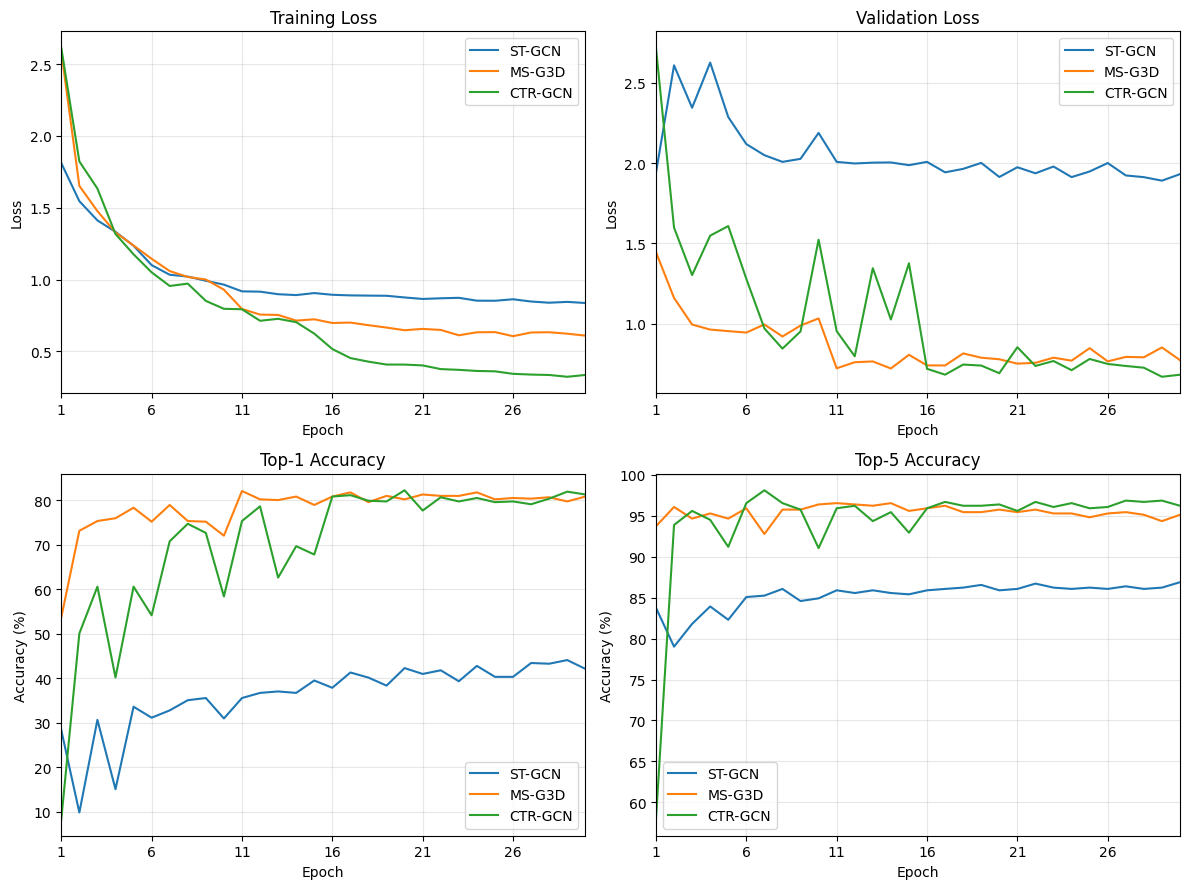

In [76]:
plot_training_metrics(
    "/kaggle/input/datasets/dandrade05/logs-gcns/log_stgcn.txt",
    "/kaggle/input/datasets/dandrade05/logs-gcns/log_msg3d.txt",
    "/kaggle/input/datasets/dandrade05/logs-gcns/log_ctr-gcn.txt",
    labels=["ST-GCN", "MS-G3D","CTR-GCN"]
)